# V1_col_7_4 Functional Correlation Analysis

This notebook uses `microns_phase3.nda` / DataJoint to access functional data, reads the filtered **126 V1 column coregistered neurons**, selects their `nda.Activity.trace` in `session=7, scan_idx=4`, and computes the empirical functional correlation matrix and eigenspectrum.

Outputs are saved under `outputs_v1_col_7_4/functional_correlation/2026-05-03/`.


In [2]:
from pathlib import Path
import os
import pickle

import numpy as np
import pandas as pd
import datajoint as dj
import matplotlib.pyplot as plt
import seaborn as sns

from microns_phase3 import nda

pd.set_option("display.max_columns", 100)
sns.set_theme(style="white", context="notebook")

SESSION = 7
SCAN_IDX = 4
SCAN_KEY = {"session": SESSION, "scan_idx": SCAN_IDX}

WORKDIR = Path.cwd()
if not (WORKDIR / "outputs_v1_col_7_4").exists() and (WORKDIR.parent / "outputs_v1_col_7_4").exists():
    WORKDIR = WORKDIR.parent
DATA_DIR_CANDIDATES = [
    WORKDIR / "functional data access and analysis",
    WORKDIR / "Functional data access and analysis",
    WORKDIR,
]
OUTDIR = WORKDIR / "outputs_v1_col_7_4"
RUN_DATE = "2026-05-03"
FUNCTIONAL_BASE_OUTDIR = OUTDIR / "functional_correlation" / RUN_DATE
FUNCTIONAL_EXAMPLE_OUTDIR = FUNCTIONAL_BASE_OUTDIR / "example"
FUNCTIONAL_CORRELATION_OUTDIR = FUNCTIONAL_BASE_OUTDIR / "correlation"
FUNCTIONAL_COUPLING_EIGEN_OUTDIR = FUNCTIONAL_BASE_OUTDIR / "coupling-eigen"
for output_dir in [OUTDIR, FUNCTIONAL_BASE_OUTDIR, FUNCTIONAL_EXAMPLE_OUTDIR, FUNCTIONAL_CORRELATION_OUTDIR, FUNCTIONAL_COUPLING_EIGEN_OUTDIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

UNITS_USED_CSV = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_units_used.csv"
EXPECTED_V1_COLUMN_UNITS = 126
SAVE_PAIRWISE_LONG_TABLE = True  # 126 个神经元只有 7,875 对，保存 long table 很轻量。

print("Working directory:", WORKDIR)
print("Output root:", OUTDIR)
print("Functional output directory:", FUNCTIONAL_BASE_OUTDIR)
print("Functional example directory:", FUNCTIONAL_EXAMPLE_OUTDIR)
print("Functional correlation directory:", FUNCTIONAL_CORRELATION_OUTDIR)
print("Functional coupling/eigen directory:", FUNCTIONAL_COUPLING_EIGEN_OUTDIR)
print("DataJoint config host:", dj.config.get("database.host"))





Connecting root@database:3306
Working directory: /notebooks/workspace
Output root: /notebooks/workspace/outputs_v1_col_7_4
Functional output directory: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03
Functional example directory: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/example
Functional correlation directory: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation
Functional coupling/eigen directory: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen
DataJoint config host: database


## 1. 确认 DataJoint 中的 scan 和 unit 数量

In [3]:
scan_rel = nda.Scan & SCAN_KEY
unit_rel = nda.ScanUnit & SCAN_KEY
activity_rel = nda.Activity & SCAN_KEY

print("Scan rows:", len(scan_rel))
print("ScanUnit rows:", len(unit_rel))
print("Activity rows:", len(activity_rel))
display(scan_rel)



Scan rows: 1
ScanUnit rows: 12675
Activity rows: 12675


session Session ID,scan_idx Scan ID,nframes number of frames per scan,nfields number of fields per scan,fps frames per second (Hz)
7,4,40000,8,6.3009


## 2. 读取已经筛选出的 V1 column 神经元数据

代码会优先在 `functional data access and analysis/` 文件夹中搜索 `.pkl/.csv/.parquet/.feather/.txt` 表格，文件名中带有 `v1`、`column`、`126` 的候选会排在最前。

理想输入表包含 `session`、`scan_idx`、`unit_id`。如果你的文件只有 126 个 `unit_id`，notebook 会默认这些 unit 属于 `session=7, scan_idx=4`。为了避免误用全量 coregistration 数据，这里不会自动退回到 CAVE 的 5625 个 matched units。

In [4]:
def _load_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix in {".pkl", ".pickle"}:
        with open(path, "rb") as f:
            obj = pickle.load(f)
        if isinstance(obj, pd.DataFrame):
            return obj
        if isinstance(obj, (list, tuple, set, np.ndarray, pd.Series)):
            return pd.DataFrame({"unit_id": list(obj)})
        if isinstance(obj, dict):
            # Common cases: {"unit_id": [...]}, {"unit_ids": [...]}, or a dataframe-like dict.
            if "unit_ids" in obj and "unit_id" not in obj:
                return pd.DataFrame({"unit_id": obj["unit_ids"]})
            return pd.DataFrame(obj)
        return pd.DataFrame(obj)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".feather":
        return pd.read_feather(path)
    if suffix == ".txt":
        values = [line.strip() for line in path.read_text().splitlines() if line.strip()]
        return pd.DataFrame({"unit_id": values})
    raise ValueError(f"Unsupported file type: {path}")


def _normalize_unit_table(df: pd.DataFrame):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    # Accept a few likely unit-id names from manual exports.
    rename_candidates = {
        "unit_ids": "unit_id",
        "unit": "unit_id",
        "functional_unit_id": "unit_id",
        "scan_unit_id": "unit_id",
    }
    for old, new in rename_candidates.items():
        if old in df.columns and new not in df.columns:
            df = df.rename(columns={old: new})

    if "unit_id" not in df.columns:
        return None

    if "session" not in df.columns:
        df["session"] = SESSION
    if "scan_idx" not in df.columns:
        df["scan_idx"] = SCAN_IDX

    df = df.dropna(subset=["unit_id"]).copy()
    df["session"] = df["session"].astype(int)
    df["scan_idx"] = df["scan_idx"].astype(int)
    df["unit_id"] = df["unit_id"].astype(int)
    return df


def find_v1_column_unit_table():
    patterns = ["*.pkl", "*.pickle", "*.csv", "*.parquet", "*.feather", "*.txt"]
    candidates = []
    for data_dir in DATA_DIR_CANDIDATES:
        if not data_dir.exists():
            continue
        for pattern in patterns:
            candidates.extend(data_dir.rglob(pattern))

    def score(path: Path) -> int:
        name = path.name.lower()
        parent = str(path.parent).lower()
        text = name + " " + parent
        strong = ["v1", "column", "126", "session7", "scan4", "s7", "scan_4"]
        weak = ["coreg", "filtered", "neuron", "functional", "unit", "max_num_scan", "ext", "exc"]
        return 10 * sum(k in text for k in strong) + sum(k in text for k in weak)

    for path in sorted(set(candidates), key=lambda p: (-score(p), len(str(p)))):
        try:
            raw = _load_table(path)
            df = _normalize_unit_table(raw)
        except Exception as exc:
            print(f"Skip {path}: {exc}")
            continue
        if df is None:
            print(f"Skip {path.name}: missing unit_id column")
            continue
        n_this_scan = df.query("session == @SESSION and scan_idx == @SCAN_IDX")["unit_id"].nunique()
        print(f"Candidate {path}: {n_this_scan} unique units for session={SESSION}, scan_idx={SCAN_IDX}")
        if n_this_scan == EXPECTED_V1_COLUMN_UNITS:
            print(f"Loaded V1 column unit table: {path}")
            return df, path

    return None, None


df_coreg_filtered, source_path = find_v1_column_unit_table()

if df_coreg_filtered is None:
    raise FileNotFoundError(
        f"没有找到包含 {EXPECTED_V1_COLUMN_UNITS} 个 V1 column unit_id 的本地文件。"
        "请把你筛选出的 V1 column 神经元表放到 'functional data access and analysis/' 文件夹，"
        "或放在当前目录；文件至少需要一列 unit_id。"
    )

print("Source:", source_path)
print("Shape:", df_coreg_filtered.shape)
display(df_coreg_filtered.head())


Candidate /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_units_used.csv: 126 unique units for session=7, scan_idx=4
Loaded V1 column unit table: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_units_used.csv
Source: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_units_used.csv
Shape: (126, 20)


,session,scan_idx,unit_id,id_ref,created_ref,valid_ref,volume,pt_supervoxel_id,pt_root_id,id,created,valid,target_id,field,residual,score,pt_position,bb_start_position,bb_end_position,target_id_ext
0,7,4,2158,292684,2020-09-28 22:45:19.428363+00:00,True,372.53873,91134396396288966,864691134950156796,50009,2024-12-18 19:02:46.471557+00:00,True,292684,2,10.304643,1.758449,[192032 112224 20746],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292684
1,7,4,2162,292889,2020-09-28 22:44:27.240567+00:00,True,254.00066,91134465250137874,864691136126503206,50013,2024-12-18 19:02:46.473745+00:00,True,292889,2,3.482782,8.972762,[191888 112464 21903],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292889
2,7,4,2196,292666,2020-09-28 22:44:02.529861+00:00,True,209.28528,90501215137650063,864691135757002450,50042,2024-12-18 19:02:46.489799+00:00,True,292666,2,13.983134,-3.248180,[187104 112880 20725],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292666
3,7,4,2197,292646,2020-09-28 22:45:13.921913+00:00,True,345.55234,89868446128941331,864691135738969220,50043,2024-12-18 19:02:46.490335+00:00,True,292646,2,6.281342,5.161610,[182528 117344 20379],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292646
4,7,4,2199,292728,2020-09-28 22:45:05.946027+00:00,True,318.60342,90360615155179836,864691136058646488,50045,2024-12-18 19:02:46.491415+00:00,True,292728,2,1.925723,8.506238,[186096 114176 21111],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292728


In [5]:
# Deliberately no CAVE fallback here.
# The CAVE coregistration table contains thousands of matched units for session7scan4;
# this analysis should use only your preselected 126 V1 column neurons.



## 3. 选取 session 7 scan 4 的 126 个 V1 column 神经元

In [6]:
df_session_scan = (
    df_coreg_filtered
    .query("session == @SESSION and scan_idx == @SCAN_IDX")
    .copy()
)

# Keep one row per functional unit. If the source table contains EM ids or V1 column metadata,
# they are preserved in df_units for downstream merging.
df_units = (
    df_session_scan
    .drop_duplicates(subset=["session", "scan_idx", "unit_id"])
    .sort_values("unit_id")
    .reset_index(drop=True)
)

unit_ids = df_units["unit_id"].astype(int).tolist()
print(f"V1 column units in session {SESSION}, scan {SCAN_IDX}: {len(unit_ids)}")
display(df_units.head())

if len(unit_ids) != EXPECTED_V1_COLUMN_UNITS:
    raise ValueError(
        f"Expected {EXPECTED_V1_COLUMN_UNITS} V1 column units, but found {len(unit_ids)}. "
        "Please check that the loaded file is your manually selected V1 column table."
    )



V1 column units in session 7, scan 4: 126


,session,scan_idx,unit_id,id_ref,created_ref,valid_ref,volume,pt_supervoxel_id,pt_root_id,id,created,valid,target_id,field,residual,score,pt_position,bb_start_position,bb_end_position,target_id_ext
0,7,4,2158,292684,2020-09-28 22:45:19.428363+00:00,True,372.53873,91134396396288966,864691134950156796,50009,2024-12-18 19:02:46.471557+00:00,True,292684,2,10.304643,1.758449,[192032 112224 20746],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292684
1,7,4,2162,292889,2020-09-28 22:44:27.240567+00:00,True,254.00066,91134465250137874,864691136126503206,50013,2024-12-18 19:02:46.473745+00:00,True,292889,2,3.482782,8.972762,[191888 112464 21903],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292889
2,7,4,2196,292666,2020-09-28 22:44:02.529861+00:00,True,209.28528,90501215137650063,864691135757002450,50042,2024-12-18 19:02:46.489799+00:00,True,292666,2,13.983134,-3.248180,[187104 112880 20725],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292666
3,7,4,2197,292646,2020-09-28 22:45:13.921913+00:00,True,345.55234,89868446128941331,864691135738969220,50043,2024-12-18 19:02:46.490335+00:00,True,292646,2,6.281342,5.161610,[182528 117344 20379],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292646
4,7,4,2199,292728,2020-09-28 22:45:05.946027+00:00,True,318.60342,90360615155179836,864691136058646488,50045,2024-12-18 19:02:46.491415+00:00,True,292728,2,1.925723,8.506238,[186096 114176 21111],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292728


## 4. Read activity traces with DataJoint

This section uses `nda.Activity.trace`, i.e. the spike-extraction activity trace. To use raw calcium fluorescence instead, bridge through `nda.ScanUnit` and `nda.Fluorescence`.


In [7]:
selected_keys = [{"session": SESSION, "scan_idx": SCAN_IDX, "unit_id": int(u)} for u in unit_ids]
selected_activity = nda.Activity & selected_keys

print("Requested units:", len(selected_keys))
print("Activity traces found:", len(selected_activity))

activity_records = selected_activity.fetch("KEY", "trace", order_by="unit_id")
keys, traces = activity_records[0], activity_records[1]
activity_unit_ids = np.array([k["unit_id"] for k in keys], dtype=int)
df_activity_units_ids = pd.DataFrame(activity_unit_ids)
# display(df_activity_units_ids.head)
UNITS_IDS_CSV = FUNCTIONAL_EXAMPLE_OUTDIR / "V1_col_7_4_activity_units_ids.csv"
df_activity_units_ids.to_csv(UNITS_IDS_CSV)
print(f"saved units ids:", UNITS_IDS_CSV)

trace_lengths = np.array([len(np.asarray(t).squeeze()) for t in traces])
print("Trace length summary:")
print(pd.Series(trace_lengths).describe())

min_len = int(trace_lengths.min())
trace_matrix = np.vstack([np.asarray(t).squeeze()[:min_len] for t in traces])
df_trace_matrix = pd.DataFrame(trace_matrix, index=activity_unit_ids)
RAW_TRACE_MATRIX_CSV = FUNCTIONAL_EXAMPLE_OUTDIR / "V1_col_7_4_raw_trace_matrix.csv"
df_trace_matrix.to_csv(RAW_TRACE_MATRIX_CSV)
print(f"saved raw activity data in:", RAW_TRACE_MATRIX_CSV)
display(df_trace_matrix.iloc[:10,:10])
print("Trace matrix shape (units x frames):", trace_matrix.shape)


# Save the exact units used.
used_units = pd.DataFrame(keys).merge(df_units, on=["session", "scan_idx", "unit_id"], how="left")
used_units.to_csv(UNITS_USED_CSV, index=False)
display(used_units.head())


Requested units: 126
Activity traces found: 126
saved units ids: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/example/V1_col_7_4_activity_units_ids.csv
Trace length summary:
count      126.0
mean     40000.0
std          0.0
min      40000.0
25%      40000.0
50%      40000.0
75%      40000.0
max      40000.0
dtype: float64
saved raw activity data in: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/example/V1_col_7_4_raw_trace_matrix.csv


,0,1,2,3,4,5,6,7,8,9
2158,9.020027e-09,8.387125e-09,7.394062e-09,8.697725e-09,7.592855e-09,8.528477e-09,1.287809e-08,1.262548e-08,1.280118e-08,1.221866e-08
2162,3.056301e-08,3.902158e-08,7.615276e-08,1.418932e-07,5.012583e-02,1.593500e-07,2.647506e-07,1.412040e-07,5.774325e-08,1.077896e-07
2196,8.897472e-09,9.320782e-09,7.353874e-09,1.243783e-08,1.662574e-08,1.818020e-08,6.861864e-08,3.739937e-07,5.889980e-08,2.705254e-08
2197,3.761713e-09,2.859487e-09,2.727001e-09,3.032520e-09,3.459613e-09,3.326191e-09,3.818766e-09,4.413717e-09,6.064507e-09,1.049082e-08
2199,1.335093e-08,8.892299e-09,8.767529e-09,7.948850e-09,8.910346e-09,9.318437e-09,1.304107e-08,1.411941e-08,1.865094e-08,1.833605e-08
2200,6.137562e-09,9.239835e-09,3.904585e-08,4.718828e-08,1.701487e-01,1.549987e+00,2.136662e-08,1.415939e-08,8.408961e-09,5.765715e-09
2201,8.431894e-09,7.599548e-09,7.839274e-09,1.489479e-08,2.649487e-08,6.783804e-08,6.383972e+00,2.966318e+00,1.986252e-08,1.030831e-08
2202,1.063937e-08,1.040855e-08,1.078424e-08,1.018090e-08,1.402796e-08,1.337263e-08,1.859002e-08,2.682342e-08,1.950847e-08,1.387016e-08
2205,1.869155e-08,2.332550e-08,3.149772e-08,3.841284e-08,5.944820e-08,6.574783e-08,2.883048e-07,6.920058e-08,3.698669e-08,2.228924e-08
2207,2.621763e-08,3.546805e-08,7.950810e-08,1.205793e-07,3.940831e+01,1.092344e-07,3.251128e-07,9.583225e-08,5.783398e-08,5.094661e-08


Trace matrix shape (units x frames): (126, 40000)


,session,scan_idx,unit_id,id_ref,created_ref,valid_ref,volume,pt_supervoxel_id,pt_root_id,id,created,valid,target_id,field,residual,score,pt_position,bb_start_position,bb_end_position,target_id_ext
0,7,4,2158,292684,2020-09-28 22:45:19.428363+00:00,True,372.53873,91134396396288966,864691134950156796,50009,2024-12-18 19:02:46.471557+00:00,True,292684,2,10.304643,1.758449,[192032 112224 20746],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292684
1,7,4,2162,292889,2020-09-28 22:44:27.240567+00:00,True,254.00066,91134465250137874,864691136126503206,50013,2024-12-18 19:02:46.473745+00:00,True,292889,2,3.482782,8.972762,[191888 112464 21903],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292889
2,7,4,2196,292666,2020-09-28 22:44:02.529861+00:00,True,209.28528,90501215137650063,864691135757002450,50042,2024-12-18 19:02:46.489799+00:00,True,292666,2,13.983134,-3.248180,[187104 112880 20725],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292666
3,7,4,2197,292646,2020-09-28 22:45:13.921913+00:00,True,345.55234,89868446128941331,864691135738969220,50043,2024-12-18 19:02:46.490335+00:00,True,292646,2,6.281342,5.161610,[182528 117344 20379],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292646
4,7,4,2199,292728,2020-09-28 22:45:05.946027+00:00,True,318.60342,90360615155179836,864691136058646488,50045,2024-12-18 19:02:46.491415+00:00,True,292728,2,1.925723,8.506238,[186096 114176 21111],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292728


## 5. Compute correlation matrix


In [ ]:
def zscore_rows(x: np.ndarray) -> np.ndarray:
    x = x.astype(float)
    mean = np.nanmean(x, axis=1, keepdims=True)
    std = np.nanstd(x, axis=1, keepdims=True)
    std[std == 0] = np.nan
    return (x - mean) / std

z_traces = zscore_rows(trace_matrix)
valid_rows = np.isfinite(z_traces).all(axis=1)

if not valid_rows.all():
    dropped = activity_unit_ids[~valid_rows]
    print(f"Dropping {len(dropped)} units with non-finite or constant traces:", dropped[:20])

z_traces_valid = z_traces[valid_rows]
valid_unit_ids = activity_unit_ids[valid_rows]
z_traces_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_zscored_activity_matrix.csv"
# z_traces_npy = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_zscored_activity_matrix.npy"
df_zscored_activity = pd.DataFrame(z_traces_valid, index=valid_unit_ids)
df_zscored_activity.to_csv(z_traces_csv)
# np.save(z_traces_valid,z_traces_npy)
print(f"zscore activty matrix shape:",z_traces_valid.shape)
print(f"saved zscored activity:", z_traces_csv)
display(df_zscored_activity.iloc[:10,:10])

# df_trace_matrix = pd.DataFrame(trace_matrix, index = valid_unit_ids)
# RAW_TRACE_MATRIX_CSV = FUNCTIONAL_EXAMPLE_OUTDIR / "V1_col_7_4_raw_trace_matrix.csv"
# df_trace_matrix.to_csv(RAW_TRACE_MATRIX_CSV)
# print(f"saved raw activity data in:", RAW_TRACE_MATRIX_CSV)
# display(df_trace_matrix.iloc[:10,:10])

corr = np.corrcoef(z_traces_valid)
corr_df = pd.DataFrame(corr, index=valid_unit_ids, columns=valid_unit_ids)

corr_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_matrix.csv"
# corr_npy = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_matrix.npy"
corr_df.to_csv(corr_csv)
# np.save(corr_npy, corr)

print("Correlation matrix shape:", corr_df.shape)
print("Saved:", corr_csv)
print("Saved:", corr_npy)
display(corr_df.iloc[:10, :10])

[[-0.1480445  -0.1480445  -0.1480445  ... -0.1480445  -0.1480445
  -0.1480445 ]
 [-0.17966245 -0.17966245 -0.17966243 ... -0.17966244 -0.17966245
  -0.17966244]
 [-0.18894319 -0.18894319 -0.18894319 ... -0.18894319 -0.18894319
  -0.18894319]
 ...
 [-0.27830221 -0.27830221 -0.2783022  ... -0.27830205 -0.27830176
  -0.27830215]
 [-0.29335709 -0.29335708 -0.293357   ... -0.29335705 -0.29335683
  -0.29335697]
 [-0.28200699 -0.28200699 -0.28200698 ...  1.88708571 -0.28200625
  -0.28200686]]
zscore activty matrix shape: (126, 40000)
saved zscored activity: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_zscored_activity_matrix.csv


,0,1,2,3,4,5,6,7,8,9
2158,-0.148044,-0.148044,-0.148044,-0.148044,-0.148044,-0.148044,-0.148044,-0.148044,-0.148044,-0.148044
2162,-0.179662,-0.179662,-0.179662,-0.179662,-0.150679,-0.179662,-0.179662,-0.179662,-0.179662,-0.179662
2196,-0.188943,-0.188943,-0.188943,-0.188943,-0.188943,-0.188943,-0.188943,-0.188943,-0.188943,-0.188943
2197,-0.179778,-0.179778,-0.179778,-0.179778,-0.179778,-0.179778,-0.179778,-0.179778,-0.179778,-0.179778
2199,-0.124493,-0.124493,-0.124493,-0.124493,-0.124493,-0.124493,-0.124493,-0.124493,-0.124493,-0.124493
2200,-0.188067,-0.188067,-0.188067,-0.188066,-0.109502,0.527624,-0.188067,-0.188067,-0.188067,-0.188067
2201,-0.204699,-0.204699,-0.204699,-0.204699,-0.204699,-0.204699,3.180454,1.368215,-0.204699,-0.204699
2202,-0.119328,-0.119328,-0.119328,-0.119328,-0.119328,-0.119328,-0.119328,-0.119328,-0.119328,-0.119328
2205,-0.144536,-0.144536,-0.144536,-0.144536,-0.144536,-0.144536,-0.144535,-0.144536,-0.144536,-0.144536
2207,-0.231830,-0.231830,-0.231830,-0.231830,14.031183,-0.231830,-0.231830,-0.231830,-0.231830,-0.231830


saved raw activity data in: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/example/V1_col_7_4_raw_trace_matrix.csv


,0,1,2,3,4,5,6,7,8,9
2158,9.020027e-09,8.387125e-09,7.394062e-09,8.697725e-09,7.592855e-09,8.528477e-09,1.287809e-08,1.262548e-08,1.280118e-08,1.221866e-08
2162,3.056301e-08,3.902158e-08,7.615276e-08,1.418932e-07,5.012583e-02,1.593500e-07,2.647506e-07,1.412040e-07,5.774325e-08,1.077896e-07
2196,8.897472e-09,9.320782e-09,7.353874e-09,1.243783e-08,1.662574e-08,1.818020e-08,6.861864e-08,3.739937e-07,5.889980e-08,2.705254e-08
2197,3.761713e-09,2.859487e-09,2.727001e-09,3.032520e-09,3.459613e-09,3.326191e-09,3.818766e-09,4.413717e-09,6.064507e-09,1.049082e-08
2199,1.335093e-08,8.892299e-09,8.767529e-09,7.948850e-09,8.910346e-09,9.318437e-09,1.304107e-08,1.411941e-08,1.865094e-08,1.833605e-08
2200,6.137562e-09,9.239835e-09,3.904585e-08,4.718828e-08,1.701487e-01,1.549987e+00,2.136662e-08,1.415939e-08,8.408961e-09,5.765715e-09
2201,8.431894e-09,7.599548e-09,7.839274e-09,1.489479e-08,2.649487e-08,6.783804e-08,6.383972e+00,2.966318e+00,1.986252e-08,1.030831e-08
2202,1.063937e-08,1.040855e-08,1.078424e-08,1.018090e-08,1.402796e-08,1.337263e-08,1.859002e-08,2.682342e-08,1.950847e-08,1.387016e-08
2205,1.869155e-08,2.332550e-08,3.149772e-08,3.841284e-08,5.944820e-08,6.574783e-08,2.883048e-07,6.920058e-08,3.698669e-08,2.228924e-08
2207,2.621763e-08,3.546805e-08,7.950810e-08,1.205793e-07,3.940831e+01,1.092344e-07,3.251128e-07,9.583225e-08,5.783398e-08,5.094661e-08


Correlation matrix shape: (126, 126)
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_matrix.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_matrix.npy


,2158,2162,2196,2197,2199,2200,2201,2202,2205,2207
2158,1.000000,0.014361,0.026958,0.032843,0.017248,0.041183,0.049235,0.031383,0.029096,0.029760
2162,0.014361,1.000000,0.010116,0.005538,-0.002228,0.012510,0.021536,0.015505,-0.003730,0.054100
2196,0.026958,0.010116,1.000000,0.053288,0.010369,0.035114,0.045281,0.042300,0.007639,0.015551
2197,0.032843,0.005538,0.053288,1.000000,0.013968,0.036463,0.021283,0.021464,0.024085,0.026712
2199,0.017248,-0.002228,0.010369,0.013968,1.000000,0.021659,0.028279,0.033804,0.033090,0.032913
2200,0.041183,0.012510,0.035114,0.036463,0.021659,1.000000,0.037862,0.045042,0.031674,0.036867
2201,0.049235,0.021536,0.045281,0.021283,0.028279,0.037862,1.000000,0.064861,0.028939,0.053265
2202,0.031383,0.015505,0.042300,0.021464,0.033804,0.045042,0.064861,1.000000,0.012072,0.026248
2205,0.029096,-0.003730,0.007639,0.024085,0.033090,0.031674,0.028939,0.012072,1.000000,0.017285
2207,0.029760,0.054100,0.015551,0.026712,0.032913,0.036867,0.053265,0.026248,0.017285,1.000000


## 6. Visualize correlation matrix and correlation distribution


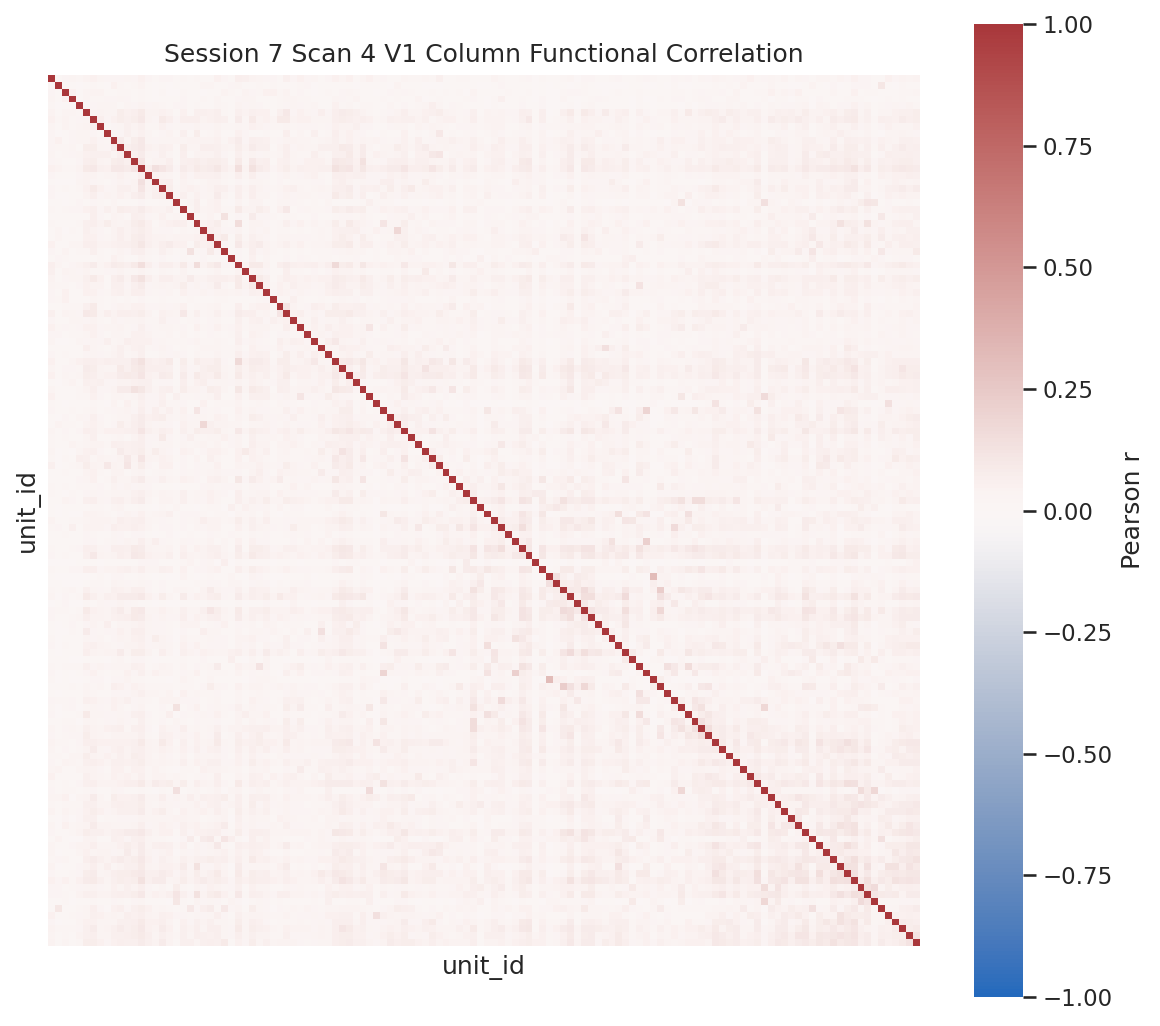

Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_heatmap.png


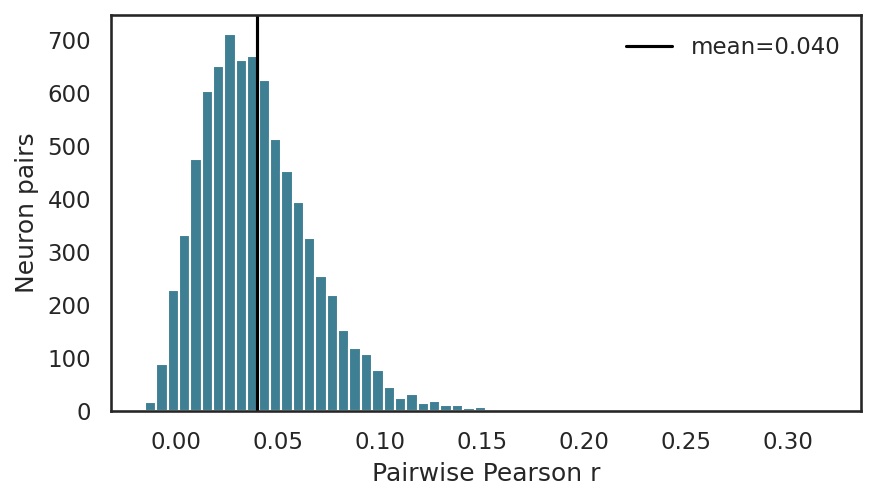

Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_distribution.png


In [102]:
fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
sns.heatmap(
    corr_df,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    square=True,
    cbar_kws={"label": "Pearson r"},
    ax=ax,
)
ax.set_title(f"Session {SESSION} Scan {SCAN_IDX} V1 Column Functional Correlation")
ax.set_xlabel("unit_id")
ax.set_ylabel("unit_id")
fig.tight_layout()
heatmap_path = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_heatmap.png"
fig.savefig(heatmap_path, bbox_inches="tight")
plt.show()
print("Saved:", heatmap_path)

upper = corr[np.triu_indices_from(corr, k=1)]
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=150)
ax.hist(upper[np.isfinite(upper)], bins=60, color="#3f7f93", edgecolor="white")
ax.axvline(np.nanmean(upper), color="black", lw=1.5, label=f"mean={np.nanmean(upper):.3f}")
ax.set_xlabel("Pairwise Pearson r")
ax.set_ylabel("Neuron pairs")
ax.legend(frameon=False)
fig.tight_layout()
hist_path = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_distribution.png"
fig.savefig(hist_path, bbox_inches="tight")
plt.show()
print("Saved:", hist_path)


## 6a. Layer-sorted correlation and covariance matrices

Sort neurons by `allen_v1_column_types_slanted_ref` layer labels, then save layer-sorted empirical activity correlation and activity covariance matrices. The row and column color bars annotate each neuron's Allen slanted V1 layer.


Loaded: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/layer_annotation/V1_col_7_4_root_id_layer_annotations.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_matrix_allen_layer_sorted.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_matrix_allen_layer_sorted.npy
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_covariance_matrix.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_covariance_matrix.npy
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_covariance_matrix_allen_layer_sorted.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_covariance_matrix_allen_layer_sorted.npy


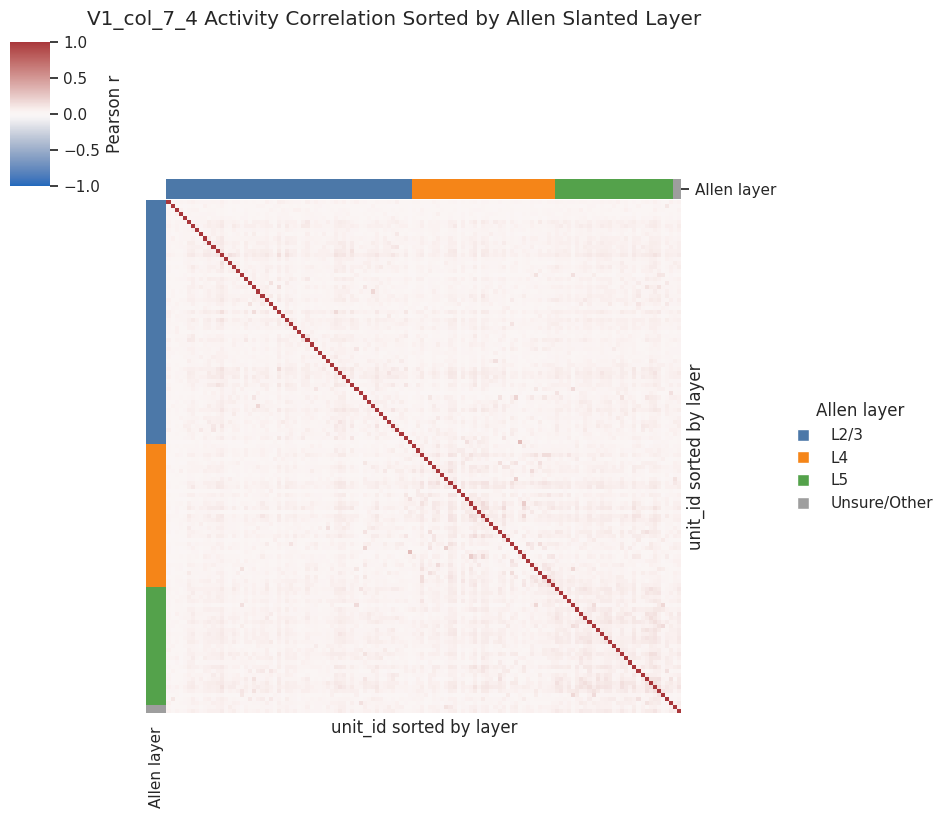

Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_allen_layer_sorted_heatmap.png


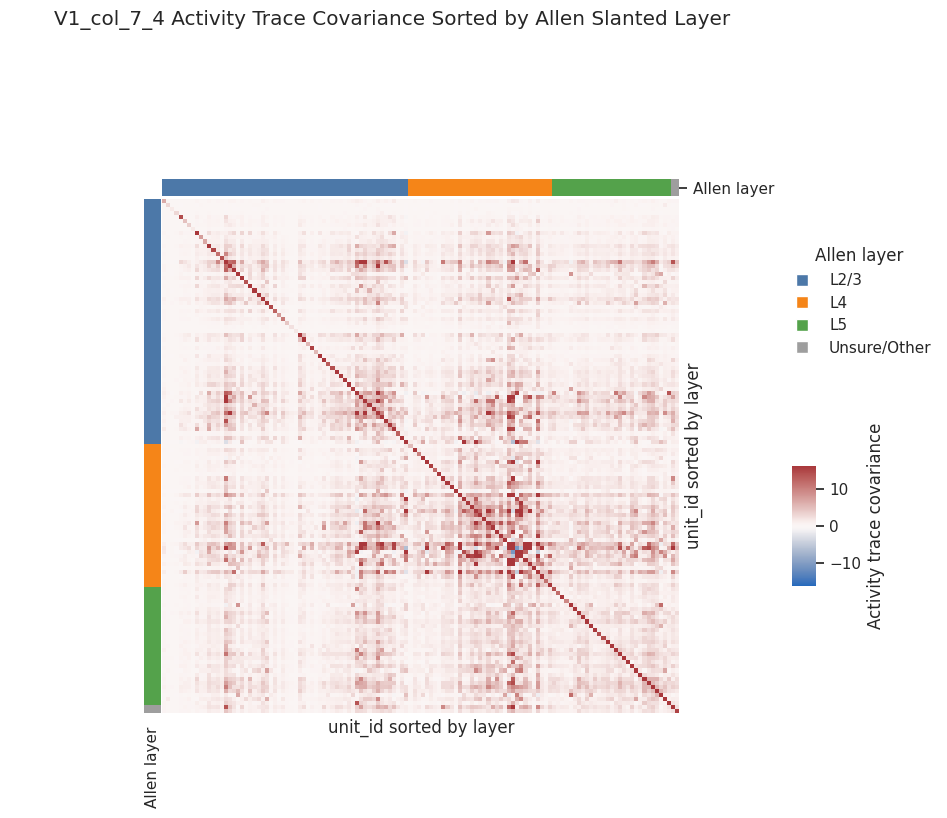

Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_covariance_allen_layer_sorted_heatmap.png


,unit_id,pt_root_id,allen_slanted_cell_type,allen_slanted_layer
0,2158,864691134950156796,23P,L2/3
1,2162,864691136126503206,23P,L2/3
2,2196,864691135757002450,23P,L2/3
3,2197,864691135738969220,23P,L2/3
4,2199,864691136058646488,23P,L2/3
5,2200,864691135943593332,23P,L2/3
6,2201,864691135540272498,23P,L2/3
7,2202,864691136211325884,23P,L2/3
8,2205,864691135701629474,23P,L2/3
9,2207,864691135587666812,23P,L2/3


,allen_slanted_layer,n_units
0,L2/3,60
1,L4,35
2,L5,29
3,Unsure/Other,2


In [103]:
LAYER_ANNOTATION_OUTDIR = FUNCTIONAL_BASE_OUTDIR / "layer_annotation"
LAYER_ANNOTATION_OUTDIR.mkdir(parents=True, exist_ok=True)
LAYER_ANNOTATION_FILENAME = "V1_col_7_4_root_id_layer_annotations.csv"
LAYER_ANNOTATION_CSV = LAYER_ANNOTATION_OUTDIR / LAYER_ANNOTATION_FILENAME

LAYER_ORDER = ["L2/3", "L4", "L5", "Unsure/Other", "Missing"]
CELL_TYPE_ORDER = ["23P", "4P", "5P-IT", "5P-PT", "Unsure E", "Missing"]
LAYER_PALETTE = {
    "L2/3": "#4C78A8",
    "L4": "#F58518",
    "L5": "#54A24B",
    "Unsure/Other": "#9E9E9E",
    "Missing": "#D3D3D3",
}


def allen_layer_from_cell_type(cell_type):
    if pd.isna(cell_type):
        return "Missing"
    cell_type = str(cell_type)
    if cell_type.startswith("23"):
        return "L2/3"
    if cell_type.startswith("4"):
        return "L4"
    if cell_type.startswith("5"):
        return "L5"
    return "Unsure/Other"


def find_existing_layer_annotation_csv():
    candidates = [
        LAYER_ANNOTATION_CSV,
        OUTDIR / "functional_correlation" / RUN_DATE / "layer_annotation" / LAYER_ANNOTATION_FILENAME,
        WORKDIR / "outputs_v1_col_7_4" / "functional_correlation" / RUN_DATE / "layer_annotation" / LAYER_ANNOTATION_FILENAME,
        WORKDIR / "notebooks" / "outputs_v1_col_7_4" / "functional_correlation" / RUN_DATE / "layer_annotation" / LAYER_ANNOTATION_FILENAME,
        WORKDIR.parent / "outputs_v1_col_7_4" / "functional_correlation" / RUN_DATE / "layer_annotation" / LAYER_ANNOTATION_FILENAME,
        WORKDIR.parent / "notebooks" / "outputs_v1_col_7_4" / "functional_correlation" / RUN_DATE / "layer_annotation" / LAYER_ANNOTATION_FILENAME,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    # Last local-only fallback: search nearby project roots. This avoids requiring CAVE auth
    # when the CSV already exists but the notebook was launched from a different cwd.
    search_roots = []
    for root in [WORKDIR, WORKDIR.parent, Path.cwd(), Path.cwd().parent]:
        if root.exists() and root not in search_roots:
            search_roots.append(root)
    for root in search_roots:
        try:
            matches = list(root.rglob(LAYER_ANNOTATION_FILENAME))
        except Exception:
            continue
        if matches:
            return matches[0]
    return None


def fetch_allen_layer_annotations_if_needed():
    existing_annotation_csv = find_existing_layer_annotation_csv()
    if existing_annotation_csv is None:
        searched_paths = [
            LAYER_ANNOTATION_CSV,
            WORKDIR / "outputs_v1_col_7_4" / "functional_correlation" / RUN_DATE / "layer_annotation" / LAYER_ANNOTATION_FILENAME,
            WORKDIR / "notebooks" / "outputs_v1_col_7_4" / "functional_correlation" / RUN_DATE / "layer_annotation" / LAYER_ANNOTATION_FILENAME,
        ]
        searched_hint = "\n".join(str(path) for path in searched_paths)
        raise FileNotFoundError(
            "Could not find the local Allen layer annotation CSV, so 6a will not try CAVE automatically "
            "because that requires an API token in this environment.\n"
            f"Expected file name: {LAYER_ANNOTATION_FILENAME}\n"
            "Put/copy the CSV to one of these locations, then rerun this cell:\n"
            f"{searched_hint}"
        )

    print("Loaded:", existing_annotation_csv)
    layer_annotations = pd.read_csv(existing_annotation_csv)
    if existing_annotation_csv != LAYER_ANNOTATION_CSV:
        layer_annotations.to_csv(LAYER_ANNOTATION_CSV, index=False)
        print("Copied to:", LAYER_ANNOTATION_CSV)
    return layer_annotations

layer_annotations = fetch_allen_layer_annotations_if_needed()
layer_annotations["allen_slanted_layer"] = layer_annotations["allen_slanted_layer"].fillna("Missing")
layer_annotations["allen_slanted_cell_type"] = layer_annotations["allen_slanted_cell_type"].fillna("Missing")

valid_layer_info = pd.DataFrame({"unit_id": valid_unit_ids}).merge(
    layer_annotations[["unit_id", "pt_root_id", "allen_slanted_cell_type", "allen_slanted_layer"]],
    on="unit_id",
    how="left",
)
valid_layer_info["allen_slanted_layer"] = valid_layer_info["allen_slanted_layer"].fillna("Missing")
valid_layer_info["allen_slanted_cell_type"] = valid_layer_info["allen_slanted_cell_type"].fillna("Missing")
valid_layer_info["layer_rank"] = valid_layer_info["allen_slanted_layer"].map({layer: i for i, layer in enumerate(LAYER_ORDER)}).fillna(len(LAYER_ORDER))
valid_layer_info["cell_type_rank"] = valid_layer_info["allen_slanted_cell_type"].map({cell_type: i for i, cell_type in enumerate(CELL_TYPE_ORDER)}).fillna(len(CELL_TYPE_ORDER))
valid_layer_info = valid_layer_info.sort_values(["layer_rank", "cell_type_rank", "unit_id"]).reset_index(drop=True)
sorted_unit_ids = valid_layer_info["unit_id"].to_numpy(dtype=int)

corr_layer_sorted_df = corr_df.loc[sorted_unit_ids, sorted_unit_ids]
corr_layer_sorted_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_matrix_allen_layer_sorted.csv"
# corr_layer_sorted_npy = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_matrix_allen_layer_sorted.npy"
corr_layer_sorted_df.to_csv(corr_layer_sorted_csv)
# np.save(corr_layer_sorted_npy, corr_layer_sorted_df.to_numpy(dtype=float))
print("Saved:", corr_layer_sorted_csv)
# print("Saved:", corr_layer_sorted_npy)

# Covariance is computed directly from activity traces, not from z-scored traces.
activity_trace_cov_source = trace_matrix[valid_rows].astype(float)
activity_cov = np.cov(activity_trace_cov_source)
activity_cov_df = pd.DataFrame(activity_cov, index=valid_unit_ids, columns=valid_unit_ids)
activity_cov_df.index.name = "unit_id"
activity_cov_df.columns.name = "unit_id"

cov_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_covariance_matrix.csv"
# cov_npy = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_covariance_matrix.npy"
activity_cov_df.to_csv(cov_csv)
# np.save(cov_npy, activity_cov)
print("Saved:", cov_csv)
# print("Saved:", cov_npy)

cov_layer_sorted_df = activity_cov_df.loc[sorted_unit_ids, sorted_unit_ids]
cov_layer_sorted_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_covariance_matrix_allen_layer_sorted.csv"
# cov_layer_sorted_npy = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_covariance_matrix_allen_layer_sorted.npy"
cov_layer_sorted_df.to_csv(cov_layer_sorted_csv)
# np.save(cov_layer_sorted_npy, cov_layer_sorted_df.to_numpy(dtype=float))
print("Saved:", cov_layer_sorted_csv)
# print("Saved:", cov_layer_sorted_npy)

layer_color_values = valid_layer_info.set_index("unit_id").loc[sorted_unit_ids, "allen_slanted_layer"].map(LAYER_PALETTE)
layer_color_values = layer_color_values.fillna(LAYER_PALETTE["Missing"])
layer_color_df = pd.DataFrame({"Allen layer": layer_color_values}, index=sorted_unit_ids)
legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=color, markersize=8, label=layer)
    for layer, color in LAYER_PALETTE.items()
    if layer in set(valid_layer_info["allen_slanted_layer"])
]

cluster_grid = sns.clustermap(
    corr_layer_sorted_df,
    row_cluster=False,
    col_cluster=False,
    row_colors=layer_color_df,
    col_colors=layer_color_df,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    figsize=(8, 8),
    cbar_kws={"label": "Pearson r"},
)
cluster_grid.fig.suptitle("V1_col_7_4 Activity Correlation Sorted by Allen Slanted Layer", y=1.02)
cluster_grid.ax_heatmap.set_xlabel("unit_id sorted by layer")
cluster_grid.ax_heatmap.set_ylabel("unit_id sorted by layer")
cluster_grid.ax_heatmap.legend(
    handles=legend_handles,
    title="Allen layer",
    loc="center left",
    bbox_to_anchor=(1.18, 0.5),
    frameon=False,
)
corr_sorted_heatmap = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_allen_layer_sorted_heatmap.png"
cluster_grid.fig.savefig(corr_sorted_heatmap, bbox_inches="tight", dpi=150)
plt.show()
print("Saved:", corr_sorted_heatmap)

cov_abs_limit = np.nanpercentile(np.abs(cov_layer_sorted_df.to_numpy(dtype=float)), 99)
if not np.isfinite(cov_abs_limit) or cov_abs_limit <= 0:
    cov_abs_limit = np.nanmax(np.abs(cov_layer_sorted_df.to_numpy(dtype=float)))
if not np.isfinite(cov_abs_limit) or cov_abs_limit <= 0:
    cov_abs_limit = 1.0
cluster_grid = sns.clustermap(
    cov_layer_sorted_df,
    row_cluster=False,
    col_cluster=False,
    row_colors=layer_color_df,
    col_colors=layer_color_df,
    colors_ratio=0.025,
    cmap="vlag",
    center=0,
    vmin=-cov_abs_limit,
    vmax=cov_abs_limit,
    xticklabels=False,
    yticklabels=False,
    figsize=(8, 8),
    cbar_kws={"label": "Activity trace covariance"},
    cbar_pos=(1, 0.3, 0.03, 0.15)
)
cluster_grid.fig.suptitle("V1_col_7_4 Activity Trace Covariance Sorted by Allen Slanted Layer", y=1.02)
cluster_grid.ax_heatmap.set_xlabel("unit_id sorted by layer")
cluster_grid.ax_heatmap.set_ylabel("unit_id sorted by layer")
cluster_grid.ax_heatmap.legend(
    handles=legend_handles,
    title="Allen layer",
    loc="center left",
    bbox_to_anchor=(1.18, 0.8),
    frameon=False,
)
cov_sorted_heatmap = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_covariance_allen_layer_sorted_heatmap.png"
cluster_grid.fig.savefig(cov_sorted_heatmap, bbox_inches="tight", dpi=150)
plt.show()
print("Saved:", cov_sorted_heatmap)

display(valid_layer_info[["unit_id", "pt_root_id", "allen_slanted_cell_type", "allen_slanted_layer"]].head(20))
display(valid_layer_info["allen_slanted_layer"].value_counts().rename_axis("allen_slanted_layer").reset_index(name="n_units"))


## 6b. Literature-style normalized activity covariance matrix

Following the covariance normalization described in the referenced paper, each neuron's activity trace is first scaled so that its mean over nonzero frames equals 1. The covariance matrix is then computed from these scaled traces and trace-normalized so that the average diagonal entry equals 1, `Tr(C) / N = 1`.


In [104]:
# Literature-style normalized covariance matrix from activity traces.
# Step 1: scale each neuron's trace so its mean over nonzero frames equals 1.
# Step 2: compute covariance with the paper's 1/T normalization.
# Step 3: trace-normalize the covariance so Tr(C) / N = 1.

activity_for_normalized_cov = trace_matrix[valid_rows].astype(float)
nonzero_means = []
nonzero_frame_fractions = []
activity_scaled_to_nonzero_mean = np.empty_like(activity_for_normalized_cov, dtype=float)

for row_idx, trace in enumerate(activity_for_normalized_cov):
    finite_nonzero = np.isfinite(trace) & (trace != 0)
    if not finite_nonzero.any():
        raise ValueError(f"Unit {valid_unit_ids[row_idx]} has no nonzero activity frames; cannot normalize nonzero mean to 1.")

    nonzero_mean = trace[finite_nonzero].mean()
    if not np.isfinite(nonzero_mean) or nonzero_mean <= 0:
        raise ValueError(
            f"Unit {valid_unit_ids[row_idx]} has nonpositive or nonfinite nonzero-frame mean "
            f"({nonzero_mean}); cannot use it as a scaling denominator."
        )

    nonzero_means.append(nonzero_mean)
    nonzero_frame_fractions.append(finite_nonzero.mean())
    activity_scaled_to_nonzero_mean[row_idx] = trace / nonzero_mean

scaled_nonzero_means = [
    activity_scaled_to_nonzero_mean[i, activity_for_normalized_cov[i] != 0].mean()
    for i in range(activity_scaled_to_nonzero_mean.shape[0])
]

activity_scaling_summary_df = pd.DataFrame(
    {
        "unit_id": valid_unit_ids,
        "nonzero_frame_fraction": nonzero_frame_fractions,
        "nonzero_mean_before_scaling": nonzero_means,
        "scale_factor": 1 / np.asarray(nonzero_means),
        "nonzero_mean_after_scaling": scaled_nonzero_means,
    }
)
activity_scaling_summary_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_nonzero_mean_scaling_summary.csv"
activity_scaling_summary_df.to_csv(activity_scaling_summary_csv, index=False)
print("Saved:", activity_scaling_summary_csv)

scaled_activity_mean_over_time = activity_scaled_to_nonzero_mean.mean(axis=1, keepdims=True)
scaled_activity_centered = activity_scaled_to_nonzero_mean - scaled_activity_mean_over_time
normalized_activity_cov = scaled_activity_centered @ scaled_activity_centered.T / activity_scaled_to_nonzero_mean.shape[1]

diag_mean_before_trace_normalization = np.trace(normalized_activity_cov) / normalized_activity_cov.shape[0]
if not np.isfinite(diag_mean_before_trace_normalization) or diag_mean_before_trace_normalization <= 0:
    raise ValueError(
        "The mean covariance diagonal is nonpositive or nonfinite; cannot trace-normalize covariance matrix."
    )

normalized_activity_cov = normalized_activity_cov / diag_mean_before_trace_normalization
normalized_activity_cov_df = pd.DataFrame(normalized_activity_cov, index=valid_unit_ids, columns=valid_unit_ids)
normalized_activity_cov_df.index.name = "unit_id"
normalized_activity_cov_df.columns.name = "unit_id"

normalized_cov_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix.csv"
# normalized_cov_npy = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix.npy"
normalized_activity_cov_df.to_csv(normalized_cov_csv)
# np.save(normalized_cov_npy, normalized_activity_cov)
print("Saved:", normalized_cov_csv)
# print("Saved:", normalized_cov_npy)

normalized_cov_layer_sorted_df = normalized_activity_cov_df.loc[sorted_unit_ids, sorted_unit_ids]
normalized_cov_layer_sorted_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted.csv"
# normalized_cov_layer_sorted_npy = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted.npy"
normalized_cov_layer_sorted_df.to_csv(normalized_cov_layer_sorted_csv)
# np.save(normalized_cov_layer_sorted_npy, normalized_cov_layer_sorted_df.to_numpy(dtype=float))
print("Saved:", normalized_cov_layer_sorted_csv)
# print("Saved:", normalized_cov_layer_sorted_npy)

print("Mean nonzero activity after per-neuron scaling:", np.mean(scaled_nonzero_means))
print("Range of nonzero activity means after scaling:", np.min(scaled_nonzero_means), np.max(scaled_nonzero_means))
print("Mean covariance diagonal before trace normalization:", diag_mean_before_trace_normalization)
print("Mean covariance diagonal after trace normalization:", np.trace(normalized_activity_cov) / normalized_activity_cov.shape[0])

display(activity_scaling_summary_df.head())
display(normalized_activity_cov_df.iloc[:5, :5])


Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_nonzero_mean_scaling_summary.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_matrix.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_matrix.npy
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted.npy
Mean nonzero activity after per-neuron scaling: 1.0
Range of nonzero activity means after scaling: 0.9999999999999997 1.0000000000000004
Mean covariance diagonal before trace normalization: 29.250585613579393
Mean covariance diagonal after trace normalization: 1.0000000000000002


,unit_id,nonzero_frame_fraction,nonzero_mean_before_scaling,scale_factor,nonzero_mean_after_scaling
0,2158,1.0,0.377600,2.648308,1.0
1,2162,1.0,0.310720,3.218329,1.0
2,2196,1.0,0.222844,4.487453,1.0
3,2197,1.0,0.308935,3.236923,1.0
4,2199,1.0,0.473034,2.114015,1.0


unit_id,2158,2162,2196,2197,2199
unit_id,,,,,
2158,1.559843,0.018459,0.032948,0.042187,0.031993
2162,0.018459,1.059133,0.010188,0.005861,-0.003405
2196,0.032948,0.010188,0.957641,0.053632,0.015071
2197,0.042187,0.005861,0.053632,1.057775,0.021337
2199,0.031993,-0.003405,0.015071,0.021337,2.205862


## 6c. Layer-sorted normalized covariance matrix

Sort the literature-style normalized covariance matrix from section 6b by Allen slanted layer labels and visualize it with the same layer color bars used for the raw covariance matrix.


Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted.npy


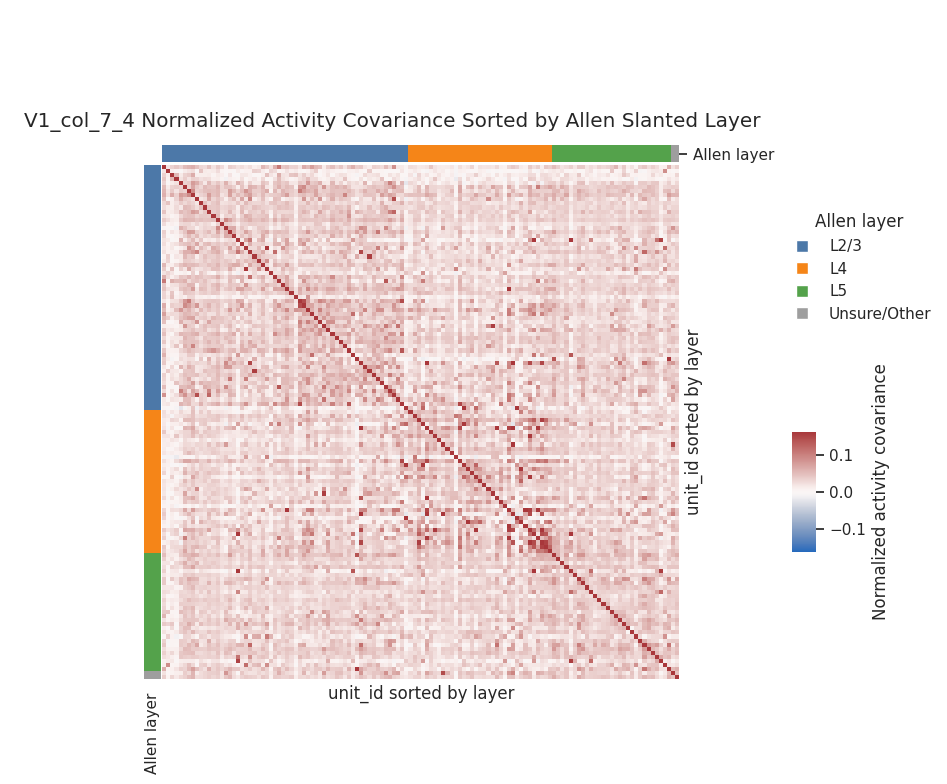

Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_allen_layer_sorted_heatmap.png
Mean diagonal after trace normalization: 0.9999999999999999


unit_id,2158,2162,2196,2197,2199
unit_id,,,,,
2158,1.559843,0.018459,0.032948,0.042187,0.031993
2162,0.018459,1.059133,0.010188,0.005861,-0.003405
2196,0.032948,0.010188,0.957641,0.053632,0.015071
2197,0.042187,0.005861,0.053632,1.057775,0.021337
2199,0.031993,-0.003405,0.015071,0.021337,2.205862


In [105]:
if "normalized_activity_cov_df" not in globals():
    normalized_cov_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix.csv"
    normalized_activity_cov_df = pd.read_csv(normalized_cov_csv, index_col=0)
    normalized_activity_cov_df.index = normalized_activity_cov_df.index.astype(int)
    normalized_activity_cov_df.columns = normalized_activity_cov_df.columns.astype(int)
    print("Loaded normalized covariance matrix:", normalized_cov_csv)

normalized_cov_layer_sorted_df = normalized_activity_cov_df.loc[sorted_unit_ids, sorted_unit_ids]
normalized_cov_layer_sorted_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted.csv"
# normalized_cov_layer_sorted_npy = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix_allen_layer_sorted.npy"
normalized_cov_layer_sorted_df.to_csv(normalized_cov_layer_sorted_csv)
# np.save(normalized_cov_layer_sorted_npy, normalized_cov_layer_sorted_df.to_numpy(dtype=float))
print("Saved:", normalized_cov_layer_sorted_csv)
# print("Saved:", normalized_cov_layer_sorted_npy)

normalized_cov_abs_limit = np.nanpercentile(np.abs(normalized_cov_layer_sorted_df.to_numpy(dtype=float)), 99)
if not np.isfinite(normalized_cov_abs_limit) or normalized_cov_abs_limit <= 0:
    normalized_cov_abs_limit = np.nanmax(np.abs(normalized_cov_layer_sorted_df.to_numpy(dtype=float)))
if not np.isfinite(normalized_cov_abs_limit) or normalized_cov_abs_limit <= 0:
    normalized_cov_abs_limit = 1.0

cluster_grid = sns.clustermap(
    normalized_cov_layer_sorted_df,
    row_cluster=False,
    col_cluster=False,
    row_colors=layer_color_df,
    col_colors=layer_color_df,
    colors_ratio=0.025,
    cmap="vlag",
    center=0,
    vmin=-normalized_cov_abs_limit,
    vmax=normalized_cov_abs_limit,
    xticklabels=False,
    yticklabels=False,
    figsize=(8, 8),
    cbar_kws={"label": "Normalized activity covariance"},
    cbar_pos=(1, 0.3, 0.03, 0.15),
)
cluster_grid.fig.suptitle("V1_col_7_4 Normalized Activity Covariance Sorted by Allen Slanted Layer", y=0.85)
cluster_grid.ax_heatmap.set_xlabel("unit_id sorted by layer")
cluster_grid.ax_heatmap.set_ylabel("unit_id sorted by layer")
cluster_grid.ax_heatmap.legend(
    handles=legend_handles,
    title="Allen layer",
    loc="center left",
    bbox_to_anchor=(1.18, 0.8),
    frameon=False,
)
normalized_cov_sorted_heatmap = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_allen_layer_sorted_heatmap.png"
cluster_grid.fig.savefig(normalized_cov_sorted_heatmap, bbox_inches="tight", dpi=150)
plt.show()
print("Saved:", normalized_cov_sorted_heatmap)

print("Mean diagonal after trace normalization:", np.trace(normalized_cov_layer_sorted_df.to_numpy(dtype=float)) / normalized_cov_layer_sorted_df.shape[0])
display(normalized_cov_layer_sorted_df.iloc[:5, :5])


## 7. Optional: save pairwise correlations as a long table

For many neurons this long table can be large; by default it is still saved here because 126 neurons only has 7,875 pairs and the table is useful for downstream joins by `unit_i/unit_j`.


In [106]:
if SAVE_PAIRWISE_LONG_TABLE:
    i_idx, j_idx = np.triu_indices_from(corr, k=1)
    pairwise_corr = pd.DataFrame({
        "unit_i": valid_unit_ids[i_idx],
        "unit_j": valid_unit_ids[j_idx],
        "pearson_r": corr[i_idx, j_idx],
    })
    pairwise_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_pairwise_activity_correlations.csv"
    pairwise_corr.to_csv(pairwise_csv, index=False)
    print("Pairwise rows:", len(pairwise_corr))
    print("Saved:", pairwise_csv)
    display(pairwise_corr.head())
else:
    n = len(valid_unit_ids)
    print(
        f"Skipped pairwise long-table export for {n} units "
        f"({n * (n - 1) // 2:,} pairs). Set SAVE_PAIRWISE_LONG_TABLE = True to save it."
    )


Pairwise rows: 7875
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_pairwise_activity_correlations.csv


,unit_i,unit_j,pearson_r
0,2158,2162,0.014361
1,2158,2196,0.026958
2,2158,2197,0.032843
3,2158,2199,0.017248
4,2158,2200,0.041183


## 8. Functional coupling correlation matrix

This section constructs a functional coupling correlation matrix from the empirical functional correlation matrix `corr_df`, without computing a coupling-derived matrix. It first zeroes the diagonal to form `W_func`, avoiding self-correlation `r=1` dominating the result; then it computes `W_func.T @ W_func`, representing similarity between neurons' full functional-correlation profiles, and trace-normalizes total spectral mass to neuron count `N`.


Functional network matrix shape: (126, 126)
Functional coupling correlation shape: (126, 126)
Trace after normalization: 126.00000000000003
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_network_offdiag_matrix.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_network_offdiag_matrix.npy
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_matrix.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_matrix.npy


unit_id,2158,2162,2196,2197,2199,2200,2201,2202,2205,2207
unit_id,,,,,,,,,,
2158,0.381750,0.123526,0.220163,0.196464,0.269942,0.558487,0.607203,0.390301,0.356667,0.490255
2162,0.123526,0.145016,0.082272,0.075362,0.101106,0.220239,0.252425,0.150968,0.107284,0.226914
2196,0.220163,0.082272,0.210202,0.123672,0.156853,0.361177,0.401737,0.255026,0.211160,0.320794
2197,0.196464,0.075362,0.123672,0.168924,0.144376,0.337496,0.352409,0.236370,0.209195,0.290959
2199,0.269942,0.101106,0.156853,0.144376,0.249511,0.447802,0.476846,0.299939,0.281409,0.374950
2200,0.558487,0.220239,0.361177,0.337496,0.447802,1.098657,1.081773,0.685570,0.627214,0.873283
2201,0.607203,0.252425,0.401737,0.352409,0.476846,1.081773,1.239151,0.726724,0.645779,0.933102
2202,0.390301,0.150968,0.255026,0.236370,0.299939,0.685570,0.726724,0.507014,0.417656,0.607206
2205,0.356667,0.107284,0.211160,0.209195,0.281409,0.627214,0.645779,0.417656,0.461525,0.500907


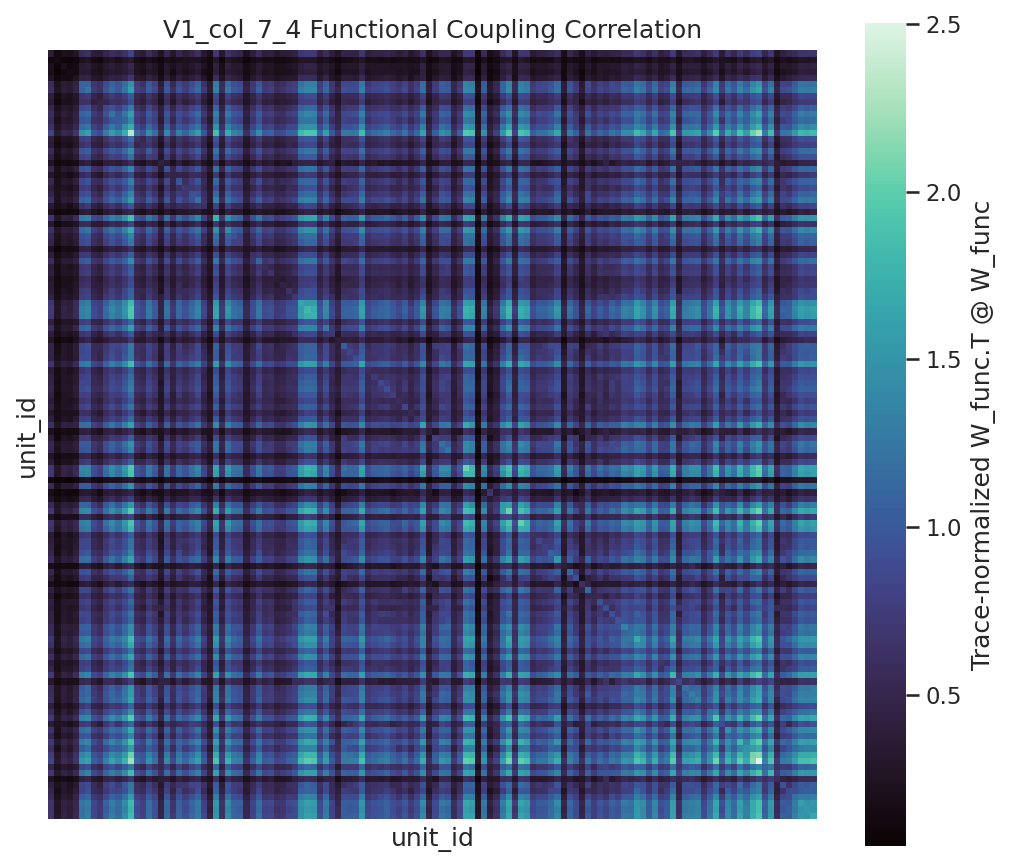

Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_heatmap.png


In [107]:
functional_corr_df = corr_df.copy().astype(float)
functional_unit_ids = functional_corr_df.index.to_numpy(dtype=int)

W_func_df = functional_corr_df.copy()
np.fill_diagonal(W_func_df.values, 0.0)
W_func_df.index.name = "unit_id"
W_func_df.columns.name = "unit_id"

functional_network_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_network_offdiag_matrix.csv"
# functional_network_npy = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_network_offdiag_matrix.npy"
W_func_df.to_csv(functional_network_csv)
# np.save(functional_network_npy, W_func_df.to_numpy(dtype=float))

FunctionalCouplingCorrelation = (W_func_df.T @ W_func_df).astype(float)
N_functional_coupling = FunctionalCouplingCorrelation.shape[0]
trace_functional_coupling = float(np.trace(FunctionalCouplingCorrelation.to_numpy(dtype=float)))
if trace_functional_coupling <= 0:
    raise ValueError("Functional coupling correlation trace is zero; cannot trace-normalize matrix.")
FunctionalCouplingCorrelation = FunctionalCouplingCorrelation / trace_functional_coupling * N_functional_coupling
FunctionalCouplingCorrelation.index.name = "unit_id"
FunctionalCouplingCorrelation.columns.name = "unit_id"
FunctionalCouplingCorrelationMatrix = FunctionalCouplingCorrelation.to_numpy(dtype="float64")

functional_coupling_corr_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_coupling_correlation_matrix.csv"
# functional_coupling_corr_npy = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_coupling_correlation_matrix.npy"
FunctionalCouplingCorrelation.to_csv(functional_coupling_corr_csv)
# np.save(functional_coupling_corr_npy, FunctionalCouplingCorrelationMatrix)

print("Functional network matrix shape:", W_func_df.shape)
print("Functional coupling correlation shape:", FunctionalCouplingCorrelation.shape)
print("Trace after normalization:", np.trace(FunctionalCouplingCorrelationMatrix))
print("Saved:", functional_network_csv)
# print("Saved:", functional_network_npy)
print("Saved:", functional_coupling_corr_csv)
# print("Saved:", functional_coupling_corr_npy)
display(FunctionalCouplingCorrelation.iloc[:10, :10])

fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
sns.heatmap(
    FunctionalCouplingCorrelation,
    cmap="mako",
    xticklabels=False,
    yticklabels=False,
    square=True,
    cbar_kws={"label": "Trace-normalized W_func.T @ W_func"},
    ax=ax,
)
ax.set_title("V1_col_7_4 Functional Coupling Correlation")
ax.set_xlabel("unit_id")
ax.set_ylabel("unit_id")
fig.tight_layout()
functional_coupling_corr_heatmap = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_coupling_correlation_heatmap.png"
fig.savefig(functional_coupling_corr_heatmap, bbox_inches="tight")
plt.show()
print("Saved:", functional_coupling_corr_heatmap)

## 9. Functional eigenspectrum under different subsampling scales

This section follows the structural-analysis notebook's subsampling method before the final eigenspectrum section: randomly sample different fractions of neurons, compute each submatrix eigenspectrum, and plot the mean spectrum and standard-deviation band across iterations. It compares two matrices: the empirical activity correlation matrix and the functional coupling correlation matrix from section 8.


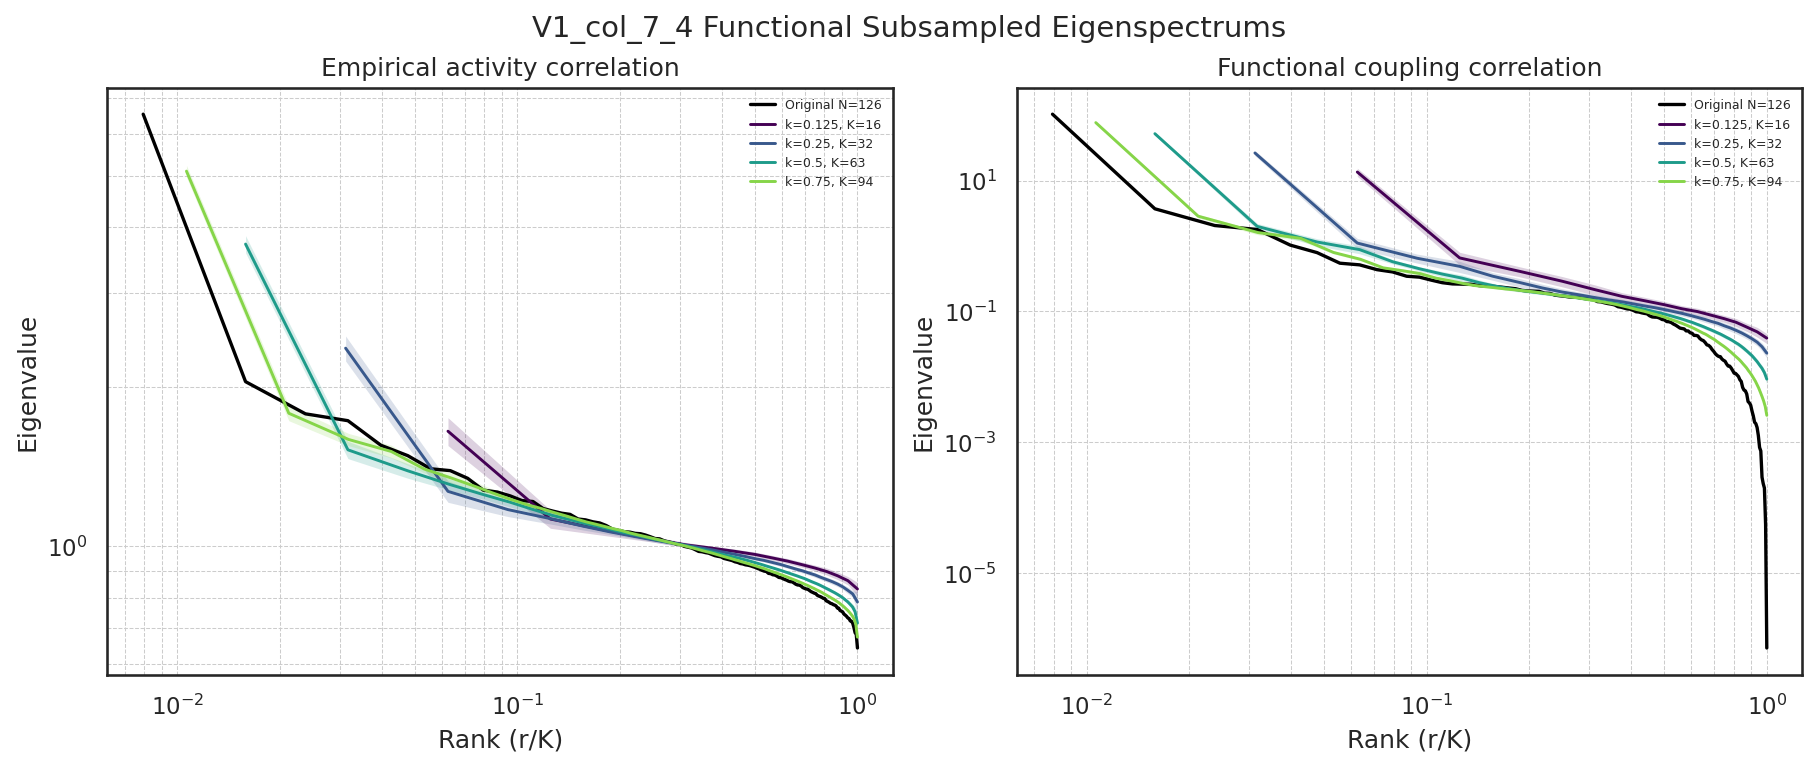

Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_subsampled_eigenspectrums.png
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_correlation_subsampled_eigenspectrum.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_subsampled_eigenspectrum.csv


,k_fraction,K,rank,rank_normalized,mean_eigenvalue,std_eigenvalue
0,0.125,16,1,0.0625,1.647862,0.099293
1,0.125,16,2,0.1250,1.125620,0.044399
2,0.125,16,3,0.1875,1.067284,0.023210
3,0.125,16,4,0.2500,1.030646,0.012283
4,0.125,16,5,0.3125,1.006272,0.010568


,k_fraction,K,rank,rank_normalized,mean_eigenvalue,std_eigenvalue
0,0.125,16,1,0.0625,13.607677,1.937141
1,0.125,16,2,0.1250,0.659138,0.144660
2,0.125,16,3,0.1875,0.411087,0.071649
3,0.125,16,4,0.2500,0.290277,0.051918
4,0.125,16,5,0.3125,0.215338,0.039046


In [108]:
def get_subsampled_eigenspectrum(matrix: np.ndarray, k_fraction: float, n_iter: int = 50, seed=None):
    """Randomly subsample K = round(N * k_fraction) neurons and average eigenspectrums."""
    matrix = np.asarray(matrix, dtype=float)
    N = matrix.shape[0]
    K = int(np.round(N * k_fraction))
    if K < 2:
        raise ValueError("Subsample size K must be at least 2.")
    rng = np.random.default_rng(seed)
    all_evals = []
    for _ in range(n_iter):
        inds = rng.choice(N, K, replace=False)
        submatrix = matrix[np.ix_(inds, inds)]
        evals = np.linalg.eigvalsh(submatrix)
        all_evals.append(np.sort(evals)[::-1])
    all_evals = np.asarray(all_evals)
    return all_evals.mean(axis=0), all_evals.std(axis=0), all_evals


def plot_subsampled_eigenspectrum(axis, matrix, title, k_fractions, n_iter=50, seed=43):
    matrix = np.asarray(matrix, dtype=float)
    original_evals = np.sort(np.linalg.eigvalsh(matrix))[::-1]
    original_ranks = (np.arange(len(original_evals)) + 1) / len(original_evals)
    original_positive = np.isfinite(original_evals) & (original_evals > 0)
    axis.loglog(
        original_ranks[original_positive],
        original_evals[original_positive],
        color="black",
        linewidth=1.6,
        label="Original N={}".format(matrix.shape[0]),
    )

    colors_sub = plt.cm.viridis(np.linspace(0, 0.82, len(k_fractions)))
    summary_rows = []
    for idx, k_fraction in enumerate(k_fractions):
        mean_evals, std_evals, _ = get_subsampled_eigenspectrum(
            matrix,
            k_fraction=k_fraction,
            n_iter=n_iter,
            seed=seed + idx,
        )
        K = len(mean_evals)
        ranks = (np.arange(K) + 1) / K
        upper = mean_evals + std_evals
        lower = mean_evals - std_evals
        positive = (
            np.isfinite(mean_evals)
            & (mean_evals > 0)
            & np.isfinite(upper)
            & (upper > 0)
        )
        if positive.any():
            safe_lower = np.maximum(lower[positive], np.finfo(float).tiny)
            axis.loglog(
                ranks[positive],
                mean_evals[positive],
                color=colors_sub[idx],
                linewidth=1.4,
                label="k={:.3g}, K={}".format(k_fraction, K),
            )
            axis.fill_between(
                ranks[positive],
                safe_lower,
                upper[positive],
                color=colors_sub[idx],
                alpha=0.18,
                linewidth=0,
            )
        for rank_idx, eigenvalue in enumerate(mean_evals, start=1):
            summary_rows.append({
                "k_fraction": k_fraction,
                "K": K,
                "rank": rank_idx,
                "rank_normalized": rank_idx / K,
                "mean_eigenvalue": eigenvalue,
                "std_eigenvalue": std_evals[rank_idx - 1],
            })

    axis.set_title(title)
    axis.set_xlabel("Rank (r/K)")
    axis.set_ylabel("Eigenvalue")
    axis.grid(True, which="both", linestyle="--", linewidth=0.5)
    axis.legend(frameon=False, fontsize=6)
    return pd.DataFrame(summary_rows)

empirical_corr_matrix = corr_df.to_numpy(dtype=float)
functional_coupling_corr_matrix = FunctionalCouplingCorrelationMatrix

k_fractions = [0.125, 0.25, 0.5, 0.75]
n_iter = 50
subsample_seed = 43

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, constrained_layout=True)
fig.suptitle("V1_col_7_4 Functional Subsampled Eigenspectrums", fontsize=14)
empirical_subsampled_eigenspectrum_df = plot_subsampled_eigenspectrum(
    axes[0],
    empirical_corr_matrix,
    "Empirical activity correlation",
    k_fractions=k_fractions,
    n_iter=n_iter,
    seed=subsample_seed,
)
functional_coupling_subsampled_eigenspectrum_df = plot_subsampled_eigenspectrum(
    axes[1],
    functional_coupling_corr_matrix,
    "Functional coupling correlation",
    k_fractions=k_fractions,
    n_iter=n_iter,
    seed=subsample_seed + 1000,
)

subsampled_eigenspectrum_png = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_subsampled_eigenspectrums.png"
fig.savefig(subsampled_eigenspectrum_png, bbox_inches="tight")
plt.show()
print("Saved:", subsampled_eigenspectrum_png)

empirical_subsampled_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_correlation_subsampled_eigenspectrum.csv"
functional_coupling_subsampled_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_coupling_correlation_subsampled_eigenspectrum.csv"
empirical_subsampled_eigenspectrum_df.to_csv(empirical_subsampled_csv, index=False)
functional_coupling_subsampled_eigenspectrum_df.to_csv(functional_coupling_subsampled_csv, index=False)
print("Saved:", empirical_subsampled_csv)
print("Saved:", functional_coupling_subsampled_csv)
display(empirical_subsampled_eigenspectrum_df.head())
display(functional_coupling_subsampled_eigenspectrum_df.head())


## 10. Empirical correlation and functional coupling correlation eigenspectrum

This section computes and visualizes eigenspectrums for two matrices: the empirical correlation matrix from activity traces, and the functional coupling correlation matrix constructed in section 8. It does not generate coupling-derived correlation.


In [109]:
def eigenspectrum_desc(matrix: np.ndarray) -> np.ndarray:
    evals = np.linalg.eigvalsh(matrix)
    return np.sort(evals)[::-1]


def fit_power_law_positive(eigenvalues: np.ndarray, num_top_eigenvalues: int = 100):
    evals = np.sort(np.asarray(eigenvalues, dtype=float))[::-1]
    positive_positions = np.flatnonzero(evals > 0)
    n_fit = min(num_top_eigenvalues, len(positive_positions))
    if n_fit < 2:
        return None
    fit_positions = positive_positions[:n_fit]
    top_evals = evals[fit_positions]
    normalized_ranks = (fit_positions + 1) / len(evals)
    log_x = np.log(normalized_ranks)
    log_y = np.log(top_evals)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    fitted_y = np.exp(slope * log_x + intercept)
    r_squared = np.corrcoef(log_x, log_y)[0, 1] ** 2
    return {
        "slope": slope,
        "intercept": intercept,
        "exponent": -slope,
        "r_squared": r_squared,
        "data_x": normalized_ranks,
        "data_y": top_evals,
        "fitted_y": fitted_y,
    }


def save_eigenspectrum_csv(eigenvalues: np.ndarray, output_path: Path):
    ranks = np.arange(1, len(eigenvalues) + 1)
    df = pd.DataFrame({
        "rank": ranks,
        "rank_normalized": ranks / len(eigenvalues),
        "eigenvalue": eigenvalues,
    })
    df.to_csv(output_path, index=False)
    print("Saved:", output_path)
    return df


def plot_positive_eigenvalues(axis, eigenvalues, label, color):
    eigenvalues = np.asarray(eigenvalues, dtype=float)
    ranks = (np.arange(len(eigenvalues)) + 1) / len(eigenvalues)
    positive = np.isfinite(eigenvalues) & (eigenvalues > 0)
    axis.loglog(ranks[positive], eigenvalues[positive], color=color, linewidth=1.5, label=label)

# empirical_corr_matrix = corr_df.to_numpy(dtype=float)
# empirical_corr_evals = eigenspectrum_desc(empirical_corr_matrix)
# functional_coupling_corr_evals = eigenspectrum_desc(FunctionalCouplingCorrelationMatrix)

# empirical_eigenspectrum_df = save_eigenspectrum_csv(
#     empirical_corr_evals,
#     FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_correlation_eigenspectrum.csv",
# )
# functional_coupling_eigenspectrum_df = save_eigenspectrum_csv(
#     functional_coupling_corr_evals,
#     FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_coupling_correlation_eigenspectrum.csv",
# )

# fit_empirical = fit_power_law_positive(empirical_corr_evals, num_top_eigenvalues=100)
# fit_functional_coupling = fit_power_law_positive(functional_coupling_corr_evals, num_top_eigenvalues=100)

# fig, ax = plt.subplots(figsize=(6.5, 4.8), dpi=150)
# plot_positive_eigenvalues(ax, empirical_corr_evals, "Empirical activity correlation", "black")
# plot_positive_eigenvalues(ax, functional_coupling_corr_evals, "Functional coupling correlation", "#2f7f8f")

# for fit, color, label in [
#     (fit_empirical, "#d54b3d", "Empirical fit"),
#     (fit_functional_coupling, "#7b4ab2", "Coupling corr fit"),
# ]:
#     if fit is not None:
#         ax.loglog(
#             fit["data_x"],
#             fit["fitted_y"],
#             "--",
#             color=color,
#             linewidth=1.3,
#             label="{} alpha={:.2f}, R2={:.2f}".format(label, fit["exponent"], fit["r_squared"]),
#         )

# ax.set_xlabel("Rank (r/N)")
# ax.set_ylabel("Eigenvalue")
# ax.set_title("V1_col_7_4 Functional Matrix Eigenspectrums")
# ax.grid(True, which="both", linestyle="--", linewidth=0.5)
# ax.legend(frameon=False, fontsize=7)
# fig.tight_layout()
# functional_eigenspectrum_png = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_correlation_and_coupling_eigenspectrums.png"
# fig.savefig(functional_eigenspectrum_png, bbox_inches="tight")
# plt.show()
# print("Saved:", functional_eigenspectrum_png)

# display(empirical_eigenspectrum_df.head(10))
# display(functional_coupling_eigenspectrum_df.head(10))


## 11. Normalized activity covariance eigenspectrum and subsampling

This section builds the eigenspectrum from the literature-style normalized covariance matrix computed in section 6b. The matrix uses activity traces scaled to unit nonzero-frame mean per neuron and is then trace-normalized so that `Tr(C) / N = 1`. The subsampling panel keeps the same plotting method while recomputing eigenspectrums on random neuron subsets of that normalized covariance matrix.


Using normalized activity covariance and empirical correlation matrices for eigenspectrum.
Normalized covariance Tr(C) / N: 1.0000000000000002
Normalized covariance diagonal range: 0.3295488631763112 2.400932709939749
Empirical correlation Tr(C) / N: 1.0
Empirical correlation diagonal range: 0.9999999999999998 1.0
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_normalized_covariance_eigenspectrum.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_normalized_covariance_diagonal_spectrum.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_correlation_eigenspectrum.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_correlation_diagonal_spectrum.csv


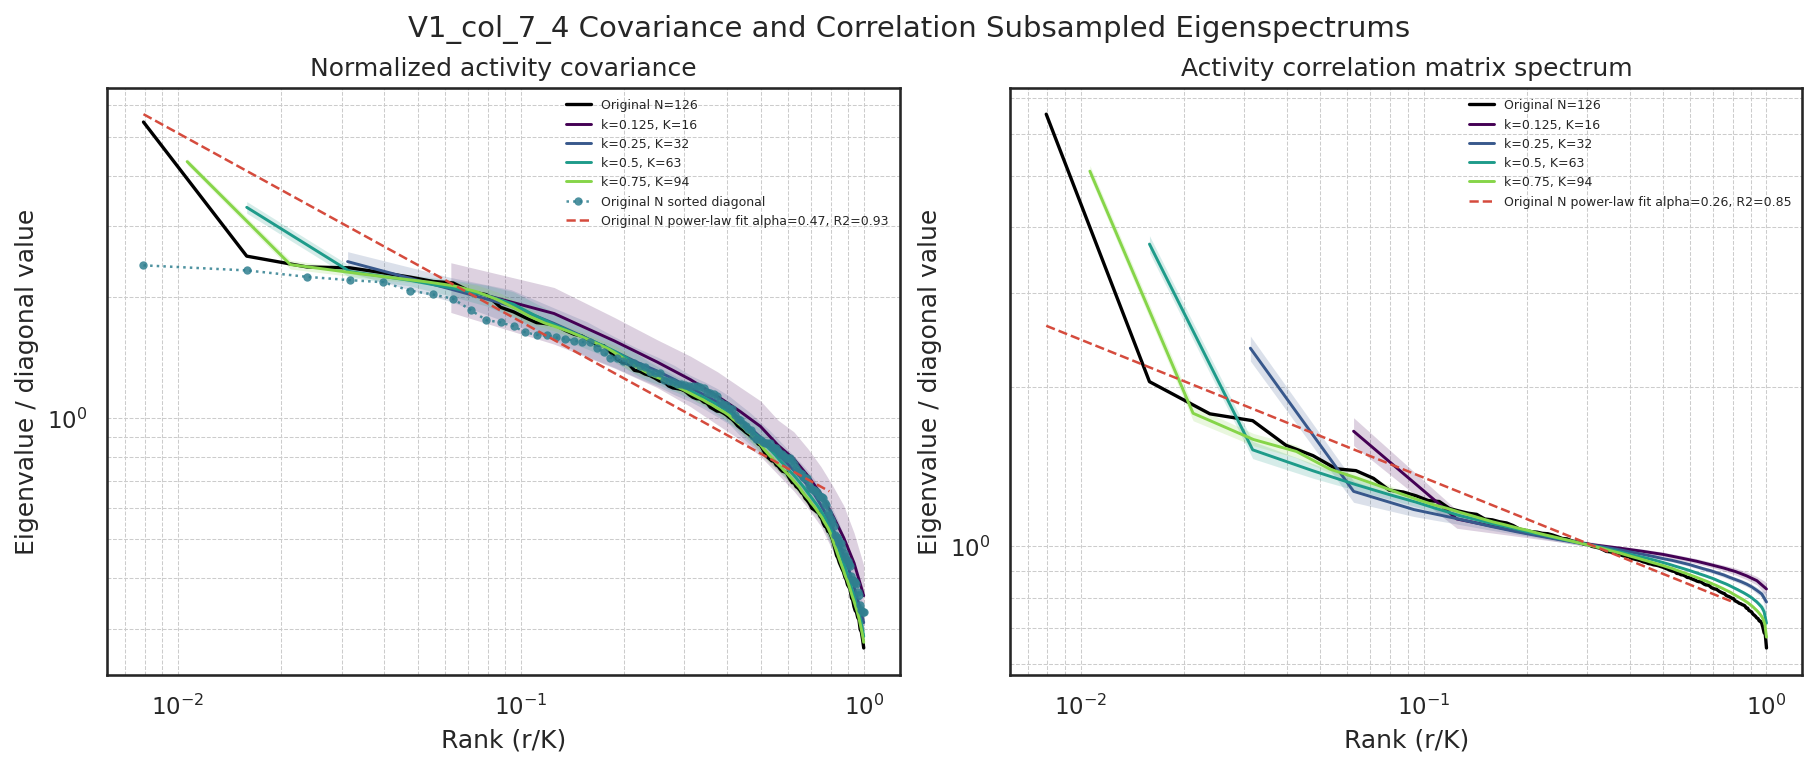

Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_covariance_left_correlation_right_subsampled_eigenspectrums.png
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_normalized_covariance_subsampled_eigenspectrum.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_correlation_subsampled_eigenspectrum.csv


,rank,rank_normalized,eigenvalue
0,1,0.007937,5.452633
1,2,0.015873,2.530829
2,3,0.023810,2.378626
3,4,0.031746,2.366914
4,5,0.039683,2.300879
5,6,0.047619,2.244057
6,7,0.055556,2.189084
7,8,0.063492,2.170525
8,9,0.071429,2.065017
9,10,0.079365,2.029961


,rank,rank_normalized,diagonal_value
0,1,0.007937,2.400933
1,2,0.015873,2.332234
2,3,0.023810,2.248135
3,4,0.031746,2.205862
4,5,0.039683,2.179768
5,6,0.047619,2.076506
6,7,0.055556,2.031980
7,8,0.063492,1.982196
8,9,0.071429,1.858757
9,10,0.079365,1.753702


,k_fraction,K,rank,rank_normalized,mean_eigenvalue,std_eigenvalue
0,0.125,16,1,0.0625,2.135159,0.301722
1,0.125,16,2,0.1250,1.822284,0.292843
2,0.125,16,3,0.1875,1.557354,0.224447
3,0.125,16,4,0.2500,1.379977,0.187619
4,0.125,16,5,0.3125,1.248059,0.179066


,rank,rank_normalized,eigenvalue
0,1,0.007937,6.524891
1,2,0.015873,2.043231
2,3,0.023810,1.776919
3,4,0.031746,1.724752
4,5,0.039683,1.550314
5,6,0.047619,1.481808
6,7,0.055556,1.400025
7,8,0.063492,1.388537
8,9,0.071429,1.343001
9,10,0.079365,1.276059


,rank,rank_normalized,diagonal_value
0,1,0.007937,1.0
1,2,0.015873,1.0
2,3,0.023810,1.0
3,4,0.031746,1.0
4,5,0.039683,1.0
5,6,0.047619,1.0
6,7,0.055556,1.0
7,8,0.063492,1.0
8,9,0.071429,1.0
9,10,0.079365,1.0


,k_fraction,K,rank,rank_normalized,mean_eigenvalue,std_eigenvalue
0,0.125,16,1,0.0625,1.647862,0.099293
1,0.125,16,2,0.1250,1.125620,0.044399
2,0.125,16,3,0.1875,1.067284,0.023210
3,0.125,16,4,0.2500,1.030646,0.012283
4,0.125,16,5,0.3125,1.006272,0.010568


In [114]:
normalized_cov_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix.csv"
if "normalized_activity_cov_df" not in globals():
    normalized_activity_cov_df = pd.read_csv(normalized_cov_csv, index_col=0)
    normalized_activity_cov_df.index = normalized_activity_cov_df.index.astype(int)
    normalized_activity_cov_df.columns = normalized_activity_cov_df.columns.astype(int)
    print("Loaded normalized covariance matrix:", normalized_cov_csv)

normalized_activity_cov_df_for_spectrum = normalized_activity_cov_df.loc[valid_unit_ids, valid_unit_ids].copy()
normalized_activity_cov_matrix = normalized_activity_cov_df_for_spectrum.to_numpy(dtype=float)
normalized_activity_cov_evals = eigenspectrum_desc(normalized_activity_cov_matrix)
normalized_activity_cov_diag = np.sort(np.diag(normalized_activity_cov_matrix))[::-1]
normalized_activity_cov_diag_ranks = (np.arange(len(normalized_activity_cov_diag)) + 1) / len(normalized_activity_cov_diag)

empirical_corr_matrix_for_spectrum = corr_df.loc[valid_unit_ids, valid_unit_ids].to_numpy(dtype=float)
empirical_corr_evals = eigenspectrum_desc(empirical_corr_matrix_for_spectrum)
empirical_corr_diag = np.sort(np.diag(empirical_corr_matrix_for_spectrum))[::-1]
empirical_corr_diag_ranks = (np.arange(len(empirical_corr_diag)) + 1) / len(empirical_corr_diag)

print("Using normalized activity covariance and empirical correlation matrices for eigenspectrum.")
print("Normalized covariance Tr(C) / N:", np.trace(normalized_activity_cov_matrix) / normalized_activity_cov_matrix.shape[0])
print("Normalized covariance diagonal range:", np.nanmin(normalized_activity_cov_diag), np.nanmax(normalized_activity_cov_diag))
print("Empirical correlation Tr(C) / N:", np.trace(empirical_corr_matrix_for_spectrum) / empirical_corr_matrix_for_spectrum.shape[0])
print("Empirical correlation diagonal range:", np.nanmin(empirical_corr_diag), np.nanmax(empirical_corr_diag))

normalized_activity_cov_eigenspectrum_df = save_eigenspectrum_csv(
    normalized_activity_cov_evals,
    FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_normalized_covariance_eigenspectrum.csv",
)
normalized_activity_cov_diag_df = pd.DataFrame({
    "rank": np.arange(1, len(normalized_activity_cov_diag) + 1),
    "rank_normalized": normalized_activity_cov_diag_ranks,
    "diagonal_value": normalized_activity_cov_diag,
})
normalized_activity_cov_diag_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_normalized_covariance_diagonal_spectrum.csv"
normalized_activity_cov_diag_df.to_csv(normalized_activity_cov_diag_csv, index=False)
print("Saved:", normalized_activity_cov_diag_csv)

empirical_corr_eigenspectrum_df = save_eigenspectrum_csv(
    empirical_corr_evals,
    FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_correlation_eigenspectrum.csv",
)
empirical_corr_diag_df = pd.DataFrame({
    "rank": np.arange(1, len(empirical_corr_diag) + 1),
    "rank_normalized": empirical_corr_diag_ranks,
    "diagonal_value": empirical_corr_diag,
})
empirical_corr_diag_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_correlation_diagonal_spectrum.csv"
empirical_corr_diag_df.to_csv(empirical_corr_diag_csv, index=False)
print("Saved:", empirical_corr_diag_csv)

fit_normalized_activity_cov = fit_power_law_positive(normalized_activity_cov_evals, num_top_eigenvalues=100)
fit_empirical_corr = fit_power_law_positive(empirical_corr_evals, num_top_eigenvalues=100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, constrained_layout=True)
fig.suptitle("V1_col_7_4 Covariance and Correlation Subsampled Eigenspectrums", fontsize=14)

normalized_activity_cov_subsampled_eigenspectrum_df = plot_subsampled_eigenspectrum(
    axes[0],
    normalized_activity_cov_matrix,
    "Normalized activity covariance",
    k_fractions=k_fractions,
    n_iter=n_iter,
    seed=subsample_seed + 2000,
)
axes[0].loglog(
    normalized_activity_cov_diag_ranks,
    normalized_activity_cov_diag,
    ":",
    color="#2f7f8f",
    linewidth=1.2,
    marker="o",
    markersize=4,
    alpha=0.85,
    markeredgewidth=0,
    label="Original N sorted diagonal",
)
if fit_normalized_activity_cov is not None:
    axes[0].loglog(
        fit_normalized_activity_cov["data_x"],
        fit_normalized_activity_cov["fitted_y"],
        "--",
        color="#d54b3d",
        linewidth=1.2,
        label="Original N power-law fit alpha={:.2f}, R2={:.2f}".format(
            fit_normalized_activity_cov["exponent"],
            fit_normalized_activity_cov["r_squared"],
        ),
    )
axes[0].set_ylabel("Eigenvalue / diagonal value")
axes[0].legend(frameon=False, fontsize=6)

empirical_corr_subsampled_eigenspectrum_df = plot_subsampled_eigenspectrum(
    axes[1],
    empirical_corr_matrix_for_spectrum,
    "Activity correlation matrix spectrum",
    k_fractions=k_fractions,
    n_iter=n_iter,
    seed=subsample_seed,
)
# axes[1].loglog(
#     empirical_corr_diag_ranks,
#     empirical_corr_diag,
#     ":",
#     color="#555555",
#     linewidth=1.2,
#     marker="o",
#     markersize=4,
#     alpha=0.85,
#     markeredgewidth=0,
#     label="Original N sorted diagonal",
# )
if fit_empirical_corr is not None:
    axes[1].loglog(
        fit_empirical_corr["data_x"],
        fit_empirical_corr["fitted_y"],
        "--",
        color="#d54b3d",
        linewidth=1.2,
        label="Original N power-law fit alpha={:.2f}, R2={:.2f}".format(
            fit_empirical_corr["exponent"],
            fit_empirical_corr["r_squared"],
        ),
    )
axes[1].set_ylabel("Eigenvalue / diagonal value")
axes[1].legend(frameon=False, fontsize=6)

activity_cov_corr_subsampled_png = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_covariance_left_correlation_right_subsampled_eigenspectrums.png"
fig.savefig(activity_cov_corr_subsampled_png, bbox_inches="tight")
plt.show()
print("Saved:", activity_cov_corr_subsampled_png)

normalized_activity_cov_subsampled_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_normalized_covariance_subsampled_eigenspectrum.csv"
empirical_corr_subsampled_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_correlation_subsampled_eigenspectrum.csv"
normalized_activity_cov_subsampled_eigenspectrum_df.to_csv(normalized_activity_cov_subsampled_csv, index=False)
empirical_corr_subsampled_eigenspectrum_df.to_csv(empirical_corr_subsampled_csv, index=False)
print("Saved:", normalized_activity_cov_subsampled_csv)
print("Saved:", empirical_corr_subsampled_csv)

display(normalized_activity_cov_eigenspectrum_df.head(10))
display(normalized_activity_cov_diag_df.head(10))
display(normalized_activity_cov_subsampled_eigenspectrum_df.head())
display(empirical_corr_eigenspectrum_df.head(10))
display(empirical_corr_diag_df.head(10))
display(empirical_corr_subsampled_eigenspectrum_df.head())


## 12. L2/3 normalized covariance eigenspectrum

Sample the Allen slanted `L2/3` neurons from the normalized covariance matrix, compute the L2/3 covariance submatrix eigenspectrum, and compare it with the full normalized covariance eigenspectrum.


Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_matrix_L23.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_normalized_covariance_matrix_L23.npy
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_normalized_covariance_L23_eigenspectrum.csv
Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_normalized_covariance_L23_vs_full_eigenspectrum_summary.csv


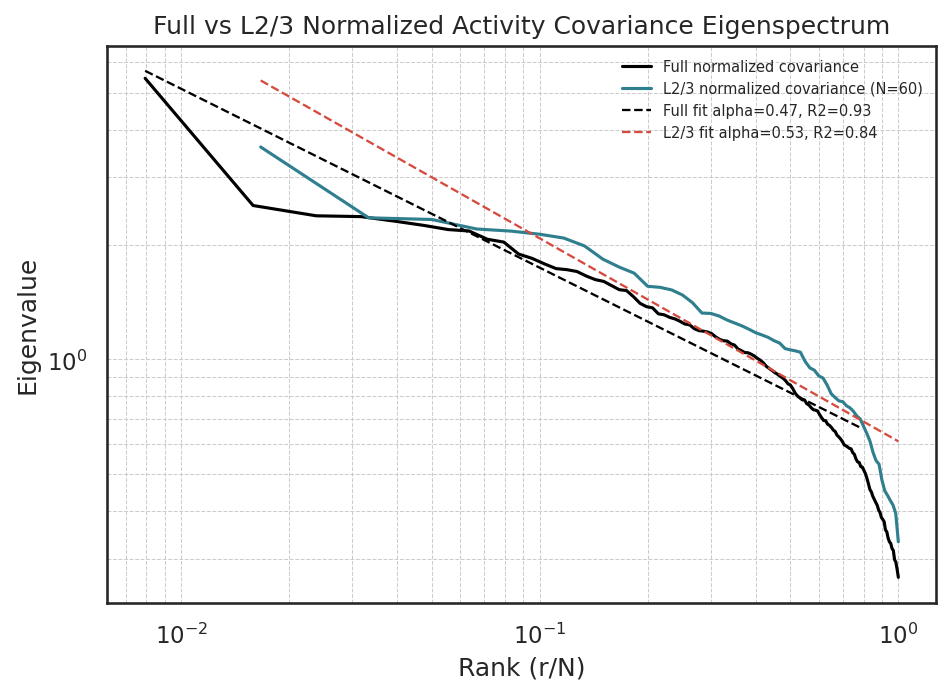

Saved: /notebooks/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_normalized_covariance_L23_vs_full_eigenspectrum.png
L2/3 neuron count: 60


,spectrum,N,trace,mean_eigenvalue,alpha,r_squared,top1_fraction,top5_fraction,top10_fraction,participation_ratio,participation_ratio_over_N
0,full_normalized_covariance,126,126.000000,1.000000,0.468735,0.926862,0.043275,0.119285,0.204195,87.357317,0.693312
1,L2/3_normalized_covariance,60,69.246746,1.154112,0.531700,0.844584,0.052022,0.182593,0.323645,46.724723,0.778745


,rank,rank_normalized,eigenvalue
0,1,0.016667,3.602381
1,2,0.033333,2.350017
2,3,0.050000,2.326398
3,4,0.066667,2.196721
4,5,0.083333,2.168457
5,6,0.100000,2.128021
6,7,0.116667,2.079949
7,8,0.133333,1.983156
8,9,0.150000,1.831012
9,10,0.166667,1.745254


In [111]:
# Compare the full normalized covariance eigenspectrum with the L2/3-only submatrix.
# This asks whether mixing neurons across layers is flattening or changing the global covariance spectrum.

normalized_cov_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix.csv"
if "normalized_activity_cov_df" not in globals():
    normalized_activity_cov_df = pd.read_csv(normalized_cov_csv, index_col=0)
    normalized_activity_cov_df.index = normalized_activity_cov_df.index.astype(int)
    normalized_activity_cov_df.columns = normalized_activity_cov_df.columns.astype(int)
    print("Loaded normalized covariance matrix:", normalized_cov_csv)

l23_unit_ids = valid_layer_info.loc[
    valid_layer_info["allen_slanted_layer"].eq("L2/3"),
    "unit_id",
].to_numpy(dtype=int)
# Keep the same layer-sorted order used in the heatmaps.
l23_unit_ids = np.asarray([unit_id for unit_id in sorted_unit_ids if unit_id in set(l23_unit_ids)], dtype=int)
if len(l23_unit_ids) < 3:
    raise ValueError(f"Need at least 3 L2/3 neurons for eigenspectrum comparison, found {len(l23_unit_ids)}.")

full_norm_cov_df = normalized_activity_cov_df.loc[valid_unit_ids, valid_unit_ids]
l23_norm_cov_df = normalized_activity_cov_df.loc[l23_unit_ids, l23_unit_ids]
full_norm_cov_matrix = full_norm_cov_df.to_numpy(dtype=float)
l23_norm_cov_matrix = l23_norm_cov_df.to_numpy(dtype=float)

full_norm_cov_evals = eigenspectrum_desc(full_norm_cov_matrix)
l23_norm_cov_evals = eigenspectrum_desc(l23_norm_cov_matrix)
fit_full_norm_cov = fit_power_law_positive(full_norm_cov_evals, num_top_eigenvalues=min(100, len(full_norm_cov_evals)))
fit_l23_norm_cov = fit_power_law_positive(l23_norm_cov_evals, num_top_eigenvalues=min(100, len(l23_norm_cov_evals)))

l23_norm_cov_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix_L23.csv"
# l23_norm_cov_npy = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_normalized_covariance_matrix_L23.npy"
l23_norm_cov_df.to_csv(l23_norm_cov_csv)
# np.save(l23_norm_cov_npy, l23_norm_cov_matrix)
print("Saved:", l23_norm_cov_csv)
# print("Saved:", l23_norm_cov_npy)

l23_norm_cov_eigenspectrum_df = save_eigenspectrum_csv(
    l23_norm_cov_evals,
    FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_normalized_covariance_L23_eigenspectrum.csv",
)


def eigenspectrum_summary(label, evals, fit):
    evals = np.asarray(evals, dtype=float)
    total = np.sum(evals)
    participation_ratio = total**2 / np.sum(evals**2) if np.sum(evals**2) > 0 else np.nan
    return {
        "spectrum": label,
        "N": len(evals),
        "trace": total,
        "mean_eigenvalue": total / len(evals),
        "alpha": np.nan if fit is None else fit["exponent"],
        "r_squared": np.nan if fit is None else fit["r_squared"],
        "top1_fraction": evals[:1].sum() / total,
        "top5_fraction": evals[:min(5, len(evals))].sum() / total,
        "top10_fraction": evals[:min(10, len(evals))].sum() / total,
        "participation_ratio": participation_ratio,
        "participation_ratio_over_N": participation_ratio / len(evals),
    }

l23_norm_cov_summary_df = pd.DataFrame([
    eigenspectrum_summary("full_normalized_covariance", full_norm_cov_evals, fit_full_norm_cov),
    eigenspectrum_summary("L2/3_normalized_covariance", l23_norm_cov_evals, fit_l23_norm_cov),
])
l23_norm_cov_summary_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_normalized_covariance_L23_vs_full_eigenspectrum_summary.csv"
l23_norm_cov_summary_df.to_csv(l23_norm_cov_summary_csv, index=False)
print("Saved:", l23_norm_cov_summary_csv)

fig, ax = plt.subplots(figsize=(6.5, 4.8), dpi=150)
plot_positive_eigenvalues(ax, full_norm_cov_evals, "Full normalized covariance", "black")
plot_positive_eigenvalues(ax, l23_norm_cov_evals, f"L2/3 normalized covariance (N={len(l23_unit_ids)})", "#2f7f8f")
if fit_full_norm_cov is not None:
    ax.loglog(
        fit_full_norm_cov["data_x"],
        fit_full_norm_cov["fitted_y"],
        "--",
        color="black",
        linewidth=1.1,
        label="Full fit alpha={:.2f}, R2={:.2f}".format(
            fit_full_norm_cov["exponent"],
            fit_full_norm_cov["r_squared"],
        ),
    )
if fit_l23_norm_cov is not None:
    ax.loglog(
        fit_l23_norm_cov["data_x"],
        fit_l23_norm_cov["fitted_y"],
        "--",
        color="#d54b3d",
        linewidth=1.1,
        label="L2/3 fit alpha={:.2f}, R2={:.2f}".format(
            fit_l23_norm_cov["exponent"],
            fit_l23_norm_cov["r_squared"],
        ),
    )
ax.set_xlabel("Rank (r/N)")
ax.set_ylabel("Eigenvalue")
ax.set_title("Full vs L2/3 Normalized Activity Covariance Eigenspectrum")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
l23_norm_cov_eigenspectrum_png = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_normalized_covariance_L23_vs_full_eigenspectrum.png"
fig.savefig(l23_norm_cov_eigenspectrum_png, bbox_inches="tight")
plt.show()
print("Saved:", l23_norm_cov_eigenspectrum_png)

print("L2/3 neuron count:", len(l23_unit_ids))
display(l23_norm_cov_summary_df)
display(l23_norm_cov_eigenspectrum_df.head(10))
